# Likelihood Exhaustive Analysis Notebook
_Autogenerated on 2025-11-01T02:42:31Z_

Run top-to-bottom.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=120

In [5]:
# === Configuration ===
import os

# Root where all likelihood outputs live
LIKELIHOOD_DIR = r"C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\likelihood"

# Subfolder where tables are stored (CSV + TEX files)
ALT_TABLES_DIR = os.path.join(LIKELIHOOD_DIR, "tables")

# Where this notebook will export figures and summary tables
OUTPUT_DIR = r"C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\likelihood_analysis_nb"

# Optional: regex to subset sites (e.g., r"^NYC|^SF"); set to None for all
SITE_FILTER_REGEX = None

# Plot and computation controls
TOP_LINEAGES = 8              # top-N lineages per site/global
MAX_SITES_PLOTS = 16          # limit per-site plots for large projects
DOWNSAMPLE_SCATTER = 150_000  # max hexbinned points in residual plots
SAVE_FIGS = False              # export PNGs + CSVs under OUTPUT_DIR
RANDOM_SEED = 12345           # reproducibility for downsampling



In [6]:

import os, re, warnings
from typing import Optional
import numpy as np, pandas as pd

np.random.seed(RANDOM_SEED)

def _all_candidate_dirs():
    cands = []
    for p in [LIKELIHOOD_DIR, ALT_TABLES_DIR]:
        if p and os.path.isdir(p): cands.append(p)
    for base in list(cands):
        for sub in ["tables", "metrics", "figures", ""]:
            d = os.path.join(base, sub)
            if os.path.isdir(d) and d not in cands:
                cands.append(d)
    return list(dict.fromkeys(cands))

def _read_csv_safely(path, **kw):
    base = dict(low_memory=False); base.update(kw)
    try: return pd.read_csv(path, **base)
    except Exception:
        try: 
            base['engine'] = 'python'
            return pd.read_csv(path, **base)
        except Exception:
            base.pop('nrows', None); base['engine'] = 'python'
            chunks = []
            for ch in pd.read_csv(path, chunksize=200_000, **base):
                chunks.append(ch)
            return pd.concat(chunks, ignore_index=True)

def _load_table_flexible(name: str) -> Optional[pd.DataFrame]:
    pats = [rf"{re.escape(name)}\.(csv|parquet)$",
            rf"{re.escape(name)}_.*\.(csv|parquet)$",
            rf".*{re.escape(name)}.*\.(csv|parquet)$"]
    for d in _all_candidate_dirs():
        try:
            for fn in os.listdir(d):
                full = os.path.join(d, fn)
                if not os.path.isfile(full): continue
                low = fn.lower()
                for pat in pats:
                    if re.match(pat, low):
                        if low.endswith('.csv'): return _read_csv_safely(full)
                        else: return pd.read_parquet(full)
        except Exception:
            continue
    return None

def _ensure_datetime(df, col='date'):
    if df is None or col not in df.columns: return df
    df = df.copy(); df[col] = pd.to_datetime(df[col], errors='coerce'); return df

def _display_df(df, name: str, max_rows=10):
    try:
        from ace_tools import display_dataframe_to_user as _disp
        _disp(name, df.head(max_rows).copy())
    except Exception:
        print(f"\\n>>> {name} (head)")
        display(df.head(max_rows))

if SAVE_FIGS:
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    figdir = os.path.join(OUTPUT_DIR, "figures"); os.makedirs(figdir, exist_ok=True)
    tbldir = os.path.join(OUTPUT_DIR, "tables"); os.makedirs(tbldir, exist_ok=True)
else:
    figdir = None; tbldir = None


In [7]:

theta = _load_table_flexible("theta_estimates")
if theta is None:
    raise FileNotFoundError("theta_estimates not found under likelihood output folders.")
theta = _ensure_datetime(theta, 'date').copy()
for c in ["site_id","sample_id","lineage"]:
    if c in theta.columns: theta[c] = theta[c].astype(str)
if 'theta' not in theta.columns:
    cand = [c for c in theta.columns if c.lower() in ('value','proportion','mix','mixture','theta_est','estimate')]
    if cand: theta = theta.rename(columns={cand[0]:'theta'})
if 'theta' not in theta.columns: raise ValueError("theta_estimates must contain 'theta'.")

residuals  = _ensure_datetime(_load_table_flexible("residuals"), 'date')
obj        = _load_table_flexible("objective_trace")
signatures = _load_table_flexible("signatures_used")
overlap    = _load_table_flexible("overlap_matrix")
zdiag      = _load_table_flexible("zscore_diagnostics")
theta_unc  = _load_table_flexible("theta_uncertainty")

_display_df(theta, "theta_estimates")
if residuals is not None: _display_df(residuals, "residuals")
if obj is not None: _display_df(obj, "objective_trace")
if signatures is not None: _display_df(signatures, "signatures_used")
if overlap is not None: _display_df(overlap, "overlap_matrix")
if zdiag is not None: _display_df(zdiag, "zscore_diagnostics")
if theta_unc is not None: _display_df(theta_unc, "theta_uncertainty")


\n>>> theta_estimates (head)


,site_id,date,sample_id,lineage,theta,median_coverage
0,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,B.1.1.7,0.471132,9202.0
1,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,B.1.351,0.175023,9202.0
2,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,B.1.617.2,0.175023,9202.0
3,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,GLOBAL,0.178762,9202.0
4,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,P.1,0.000060,9202.0
5,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,B.1.1.7,0.325072,17564.0
6,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,B.1.351,0.248632,17564.0
7,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,B.1.617.2,0.248632,17564.0
8,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,GLOBAL,0.177663,17564.0
9,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,P.1,0.000000,17564.0


\n>>> residuals (head)


,site_id,date,sample_id,mutation,obs_af,pred_af,residual,coverage,kappa_used,weight
0,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:E:P71L,0.000000,0.178762,-0.178762,1194.0,0.000001,1.0
1,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:M:I82T,0.000257,0.178762,-0.178505,35046.0,1000000.000000,1.0
2,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:D377Y,0.003394,0.178762,-0.175367,1473.0,1000000.000000,1.0
3,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:D3L,0.000000,0.178762,-0.178762,263877.0,0.000001,1.0
4,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:D63G,0.000078,0.178762,-0.178684,370990.0,99025.613209,1.0
5,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:P80R,0.000145,0.178762,-0.178617,117181.0,1000000.000000,1.0
6,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:R203M,0.000578,0.178762,-0.178184,1729.0,1000000.000000,1.0
7,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:S235F,0.317905,0.178762,0.139143,1642.0,1000000.000000,1.0
8,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:T205I,0.000000,0.178762,-0.178762,1733.0,0.000001,1.0
9,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:ORF1A:A1708D,1.000000,0.178762,0.821238,4.0,0.000001,1.0


\n>>> objective_trace (head)


...

,B.1.1.7,B.1.351,B.1.617.2,GLOBAL,P.1
0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0


\n>>> zscore_diagnostics (head)


,site_id,date,sample_id,mutation,z,coverage,pred_af,obs_af,kappa_used
0,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:E:P71L,-0.659533,1194.0,0.178762,0.000000,0.000001
1,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:M:I82T,-85.727124,35046.0,0.178762,0.000257,1000000.000000
2,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:D377Y,-17.553309,1473.0,0.178762,0.003394,1000000.000000
3,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:D3L,-0.659808,263877.0,0.178762,0.000000,0.000001
4,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:D63G,-130.381410,370990.0,0.178762,0.000078,99025.613209
5,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:P80R,-150.979313,117181.0,0.178762,0.000145,1000000.000000
6,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:R203M,-19.320491,1729.0,0.178762,0.000578,1000000.000000
7,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:S235F,14.703478,1642.0,0.178762,0.317905,1000000.000000
8,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:N:T205I,-0.659618,1733.0,0.178762,0.000000,0.000001
9,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,AA:ORF1A:A1708D,2.711172,4.0,0.178762,1.000000,0.000001


\n>>> theta_uncertainty (head)


,site_id,date,sample_id,lineage,theta_sd
0,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,B.1.1.7,2.050574e-03
1,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,B.1.351,4.308455e+01
2,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,B.1.617.2,4.308455e+01
3,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,GLOBAL,3.215815e-04
4,BE - Laupen - ARA Sensetal,2021-02-01,BE - Laupen - ARA Sensetal__date,P.1,5.897625e-05
5,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,B.1.1.7,1.255954e-03
6,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,B.1.351,2.608444e+01
7,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,B.1.617.2,2.608444e+01
8,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,GLOBAL,3.724016e-04
9,BE - Laupen - ARA Sensetal,2021-02-02,BE - Laupen - ARA Sensetal__date,P.1,5.000000e-07


In [8]:

import re as _re
if SITE_FILTER_REGEX:
    pat = _re.compile(SITE_FILTER_REGEX)
    keep = [s for s in theta['site_id'].astype(str).unique() if pat.search(s)]
    theta = theta[theta['site_id'].isin(keep)].copy()
    if residuals is not None: residuals = residuals[residuals['site_id'].isin(keep)].copy()
    if obj is not None and 'site_id' in obj.columns: obj = obj[obj['site_id'].isin(keep)].copy()
    print(f"Applied site filter; kept {len(keep)} sites.")
else:
    print("No site filter applied.")


No site filter applied.


In [9]:

import numpy as np, pandas as pd
def _weighted_stats(obs, pred, w):
    obs = np.asarray(obs, float); pred = np.asarray(pred, float); w = np.maximum(np.asarray(w, float), 0.0)
    m = np.isfinite(obs) & np.isfinite(pred) & np.isfinite(w) & (w>0)
    if not np.any(m): return dict(mae=np.nan, rmse=np.nan, brier=np.nan, r=np.nan, n=0)
    obs=obs[m]; pred=pred[m]; w=w[m]; W=w.sum()
    mae = np.sum(w*np.abs(obs-pred))/W
    rmse = np.sqrt(np.sum(w*(obs-pred)**2)/W)
    brier = np.sum(w*(obs-pred)**2)/W
    oc = obs - np.average(obs, weights=w); pc = pred - np.average(pred, weights=w)
    cov = np.sum(w*oc*pc)/W; vo = np.sum(w*oc**2)/W; vp = np.sum(w*pc**2)/W
    r = cov/np.sqrt(max(vo,1e-15)*max(vp,1e-15))
    return dict(mae=float(mae), rmse=float(rmse), brier=float(brier), r=float(r), n=int(m.sum()))

def _weighted_linreg(y, x, w):
    y = np.asarray(y, float); x = np.asarray(x, float); w = np.asarray(w, float)
    m = np.isfinite(y)&np.isfinite(x)&np.isfinite(w)&(w>0)
    if not np.any(m): return np.nan, np.nan
    y=y[m]; x=x[m]; w=w[m]; W=w.sum()
    xb = (w*x).sum()/W; yb=(w*y).sum()/W
    Sxx = (w*(x-xb)**2).sum()
    if Sxx<=0: return yb, np.nan
    Sxy = (w*(x-xb)*(y-yb)).sum()
    b = Sxy/Sxx; a = yb - b*xb
    return float(a), float(b)


In [10]:

if residuals is None:
    print("No residuals table found — metrics & calibration plots will be skipped.")
    metrics_global = pd.DataFrame()
else:
    r = residuals.copy()
    need = {"obs_af","pred_af","coverage"}
    if not need.issubset(r.columns): raise ValueError(f"residuals is missing {need - set(r.columns)}")
    stats = _weighted_stats(r['obs_af'], r['pred_af'], np.maximum(r['coverage'],1.0))
    a,b = _weighted_linreg(r['obs_af'], r['pred_af'], np.maximum(r['coverage'],1.0))
    metrics_global = pd.DataFrame([{"mae":stats['mae'],"rmse":stats['rmse'],"brier":stats['brier'],"pearson_r":stats['r'],"cal_intercept":a,"cal_slope":b,"N":stats['n']}])
    display(metrics_global)


,mae,rmse,brier,pearson_r,cal_intercept,cal_slope,N
0,0.219207,0.280055,0.078431,0.352947,-0.047654,0.7936,97650


In [11]:

metrics_by_site = pd.DataFrame()
if residuals is not None:
    rows=[]
    for sid, g in residuals.groupby('site_id', sort=False):
        st = _weighted_stats(g['obs_af'], g['pred_af'], np.maximum(g['coverage'],1.0))
        a,b = _weighted_linreg(g['obs_af'], g['pred_af'], np.maximum(g['coverage'],1.0))
        rows.append({"site_id":sid,"mae":st['mae'],"rmse":st['rmse'],"brier":st['brier'],"pearson_r":st['r'],"cal_intercept":a,"cal_slope":b,"N":st['n']})
    metrics_by_site = pd.DataFrame(rows).sort_values("rmse")
    display(metrics_by_site.head(20))


,site_id,mae,rmse,brier,pearson_r,cal_intercept,cal_slope,N
3,TI - Lugano - CDA Lugano,0.198286,0.261473,0.068368,0.345521,-0.039893,0.744215,16864
0,BE - Laupen - ARA Sensetal,0.203314,0.268185,0.071923,0.371170,-0.043839,0.778693,17112
2,SG - Altenrhein - ARA Altenrhein,0.218817,0.281681,0.079344,0.369270,-0.052899,0.827741,17856
5,ZH - ZÃ¼rich - ARA WerdhÃ¶lzli,0.223989,0.283282,0.080249,0.344772,-0.046753,0.790835,18414
1,GR - Chur - ARA Chur,0.232530,0.289326,0.083709,0.319418,-0.044512,0.766618,17236
4,VD - Lausanne - STEP Vidy,0.262972,0.314257,0.098758,0.396380,-0.084429,0.968810,10168


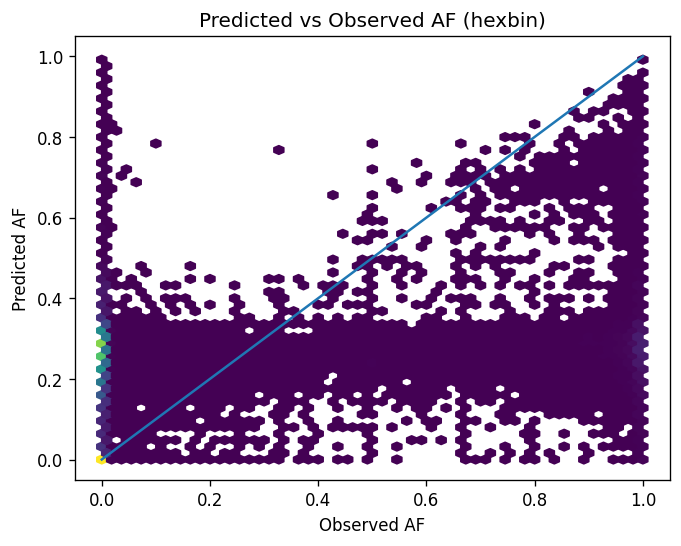

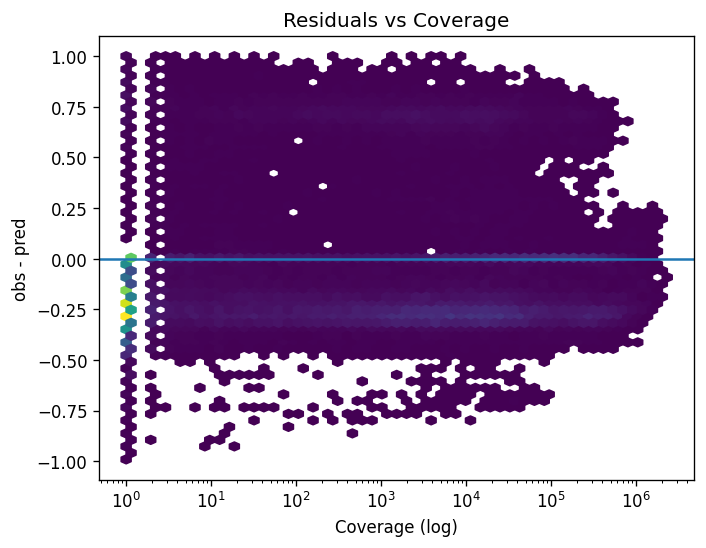

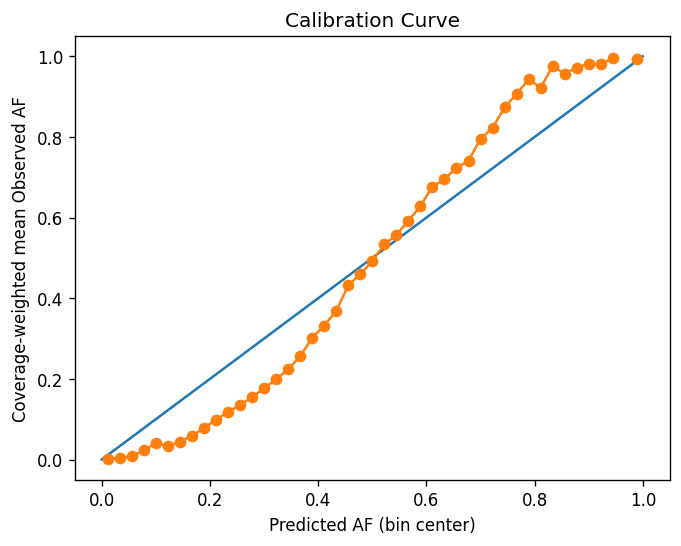

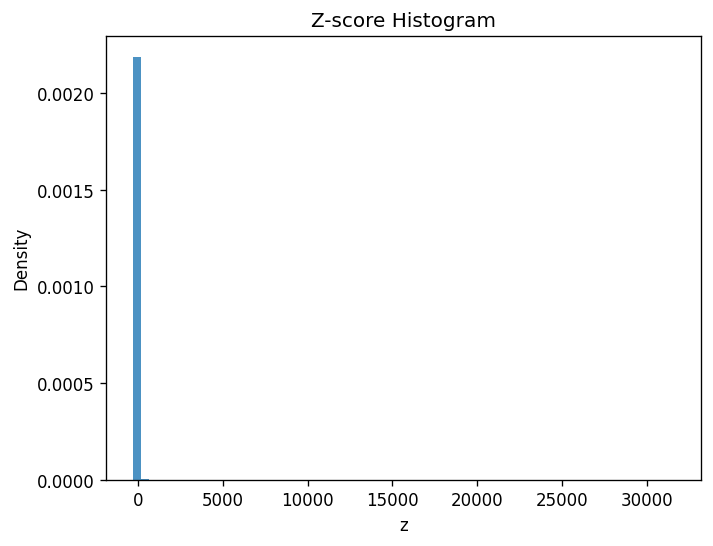

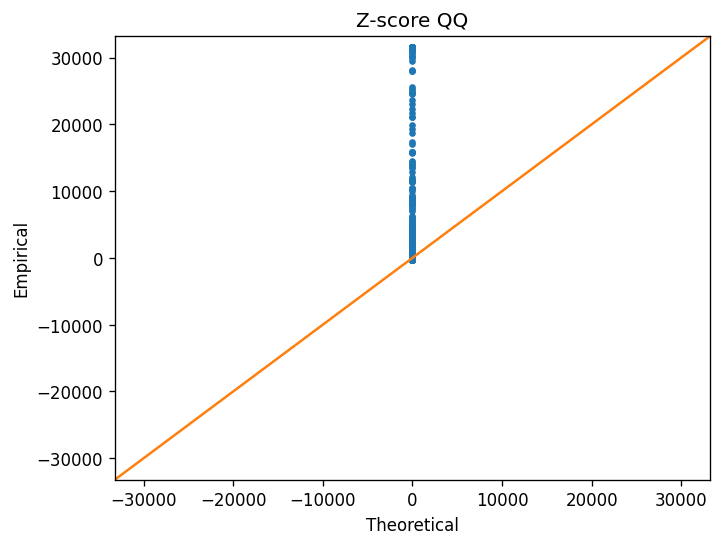

In [12]:

import matplotlib.pyplot as plt, numpy as np
if residuals is not None and len(residuals)>0:
    r = residuals[['obs_af','pred_af','coverage']].dropna().copy()
    if len(r) > DOWNSAMPLE_SCATTER:
        r = r.sample(DOWNSAMPLE_SCATTER, random_state=RANDOM_SEED)

    # Pred vs Obs hexbin
    plt.figure(); plt.hexbin(r['obs_af'], r['pred_af'], gridsize=55, mincnt=2); plt.plot([0,1],[0,1])
    plt.xlabel("Observed AF"); plt.ylabel("Predicted AF"); plt.title("Predicted vs Observed AF (hexbin)")
    plt.show()

    # Residuals vs coverage
    plt.figure(); x = np.maximum(r['coverage'].to_numpy(float),1.0); y=(r['obs_af']-r['pred_af']).to_numpy(float)
    plt.hexbin(x, y, xscale="log", gridsize=55, mincnt=2); plt.axhline(0.0)
    plt.xlabel("Coverage (log)"); plt.ylabel("obs - pred"); plt.title("Residuals vs Coverage"); plt.show()

    # Calibration curve
    plt.figure()
    p = r['pred_af'].to_numpy(float); n = np.maximum(r['coverage'].to_numpy(float),0.0); y=r['obs_af'].to_numpy(float)
    bins = np.linspace(0,1,46); idx=np.clip(np.digitize(p,bins)-1,0,44); xc=0.5*(bins[:-1]+bins[1:]); curve=[]
    for b in range(45):
        m=(idx==b)
        curve.append(np.sum(n[m]*y[m])/np.sum(n[m]) if np.any(m) and np.sum(n[m])>0 else np.nan)
    plt.plot([0,1],[0,1]); plt.plot(xc, curve, marker="o")
    plt.xlabel("Predicted AF (bin center)"); plt.ylabel("Coverage-weighted mean Observed AF"); plt.title("Calibration Curve")
    plt.show()

    # Z histogram
    if zdiag is not None and 'z' in zdiag.columns:
        z = zdiag['z'].dropna().to_numpy(float)
        if z.size>0:
            plt.figure()
            bins = max(30, min(70, int(np.sqrt(z.size))))
            plt.hist(z, bins=bins, density=True, alpha=0.8)
            plt.title("Z-score Histogram"); plt.xlabel("z"); plt.ylabel("Density"); plt.show()

            # QQ
            plt.figure()
            z_sorted=np.sort(z); ppos=(np.arange(1,z_sorted.size+1)-0.5)/z_sorted.size
            try: q = np.sqrt(2.0)*np.erfinv(2*ppos-1)
            except Exception: q = np.log(ppos/(1-ppos))/1.702
            plt.plot(q, z_sorted, marker=".", linestyle="none")
            lim = 1.05*np.nanmax(np.abs(np.concatenate([q,z_sorted]))); lim=max(lim,1.0)
            plt.plot([-lim,lim],[-lim,lim]); plt.xlim(-lim,lim); plt.ylim(-lim,lim)
            plt.xlabel("Theoretical"); plt.ylabel("Empirical"); plt.title("Z-score QQ"); plt.show()
else:
    print("Skipping residual plots (no residuals).")


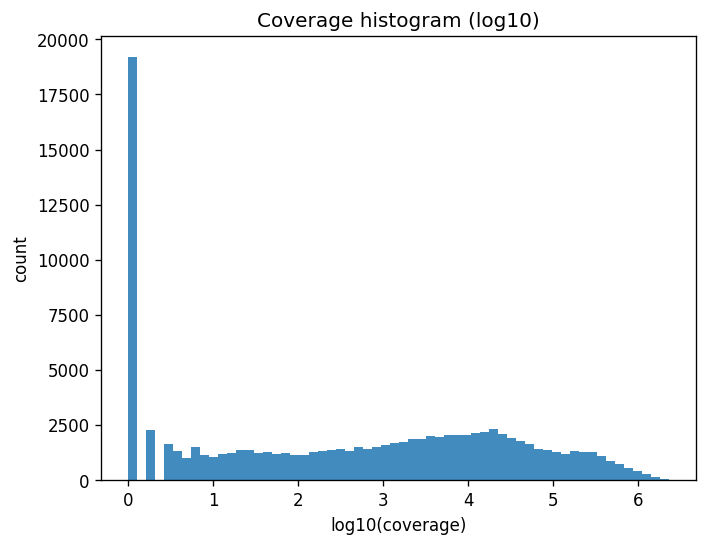

In [13]:

if residuals is not None and 'coverage' in residuals.columns:
    import numpy as np, matplotlib.pyplot as plt
    plt.figure(); cov = residuals['coverage'].astype(float).clip(lower=0.0).replace([np.inf,-np.inf],np.nan).dropna()
    plt.hist(np.log10(np.maximum(cov,1.0)), bins=60, alpha=0.85)
    plt.xlabel("log10(coverage)"); plt.ylabel("count"); plt.title("Coverage histogram (log10)"); plt.show()


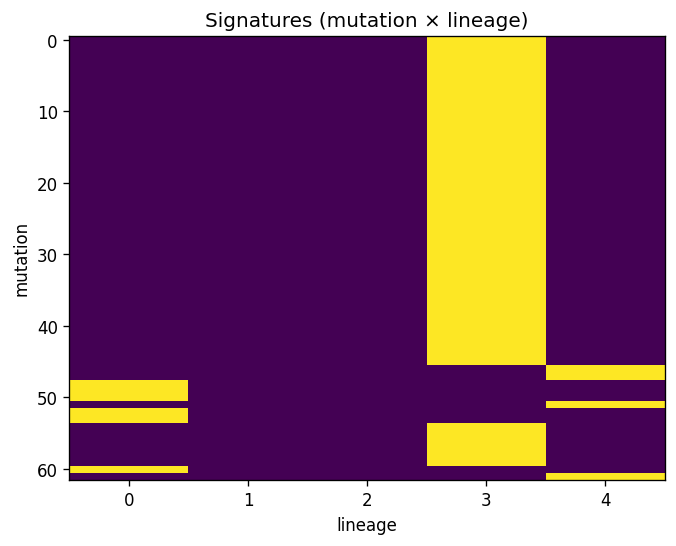

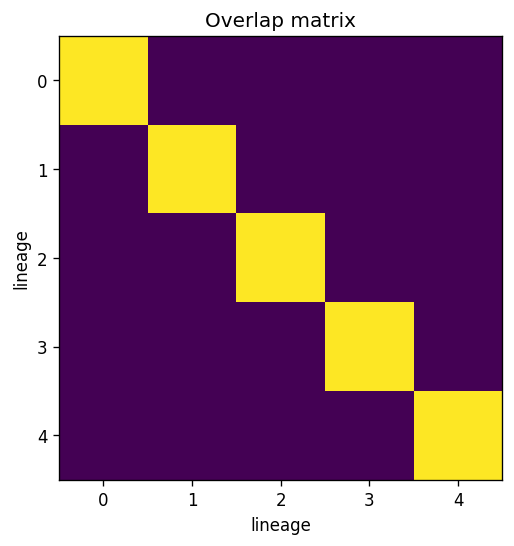

In [14]:

def _as_signature_matrix(df):
    if df is None: return None, None, None
    D = df.copy()
    if 'mutation' in D.columns and any(c for c in D.columns if c not in ('mutation',) and D[c].dtype!=object):
        cols = [c for c in D.columns if c!='mutation']
        M = D.set_index('mutation')[cols].astype(float)
        return M.values, list(M.index), list(M.columns)
    if {'mutation','lineage','weight'}.issubset(D.columns):
        P = D.pivot_table(index='mutation', columns='lineage', values='weight', fill_value=0.0)
        return P.values, list(P.index), list(P.columns)
    return None, None, None

S, S_mut, S_lin = _as_signature_matrix(signatures)
if S is not None:
    import matplotlib.pyplot as plt
    plt.figure(); plt.imshow(S, aspect='auto', interpolation='nearest')
    plt.title("Signatures (mutation × lineage)"); plt.xlabel("lineage"); plt.ylabel("mutation"); plt.show()

if overlap is not None:
    try:
        import matplotlib.pyplot as plt
        M = overlap.copy()
        plt.figure(); plt.imshow(M.values.astype(float), aspect='equal', interpolation='nearest')
        plt.title("Overlap matrix"); plt.xlabel("lineage"); plt.ylabel("lineage"); plt.show()
    except Exception as e:
        warnings.warn(f"Overlap heatmap failed: {e}")


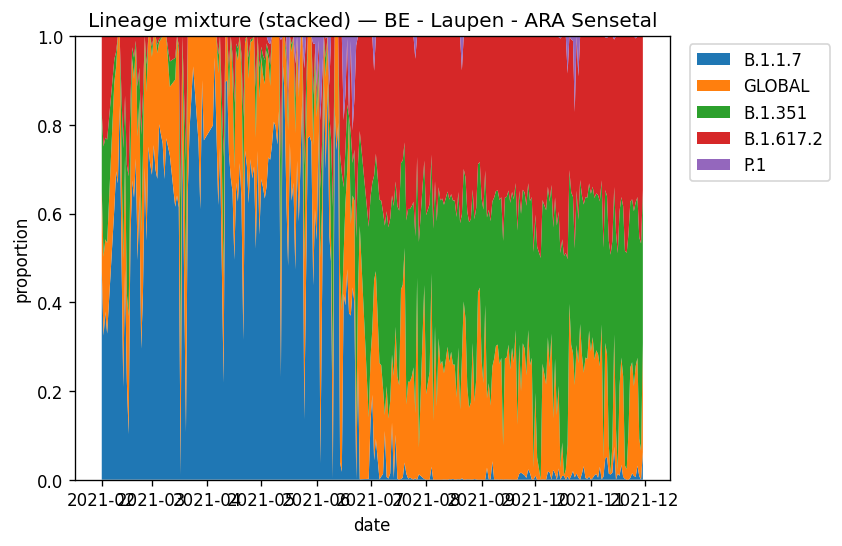

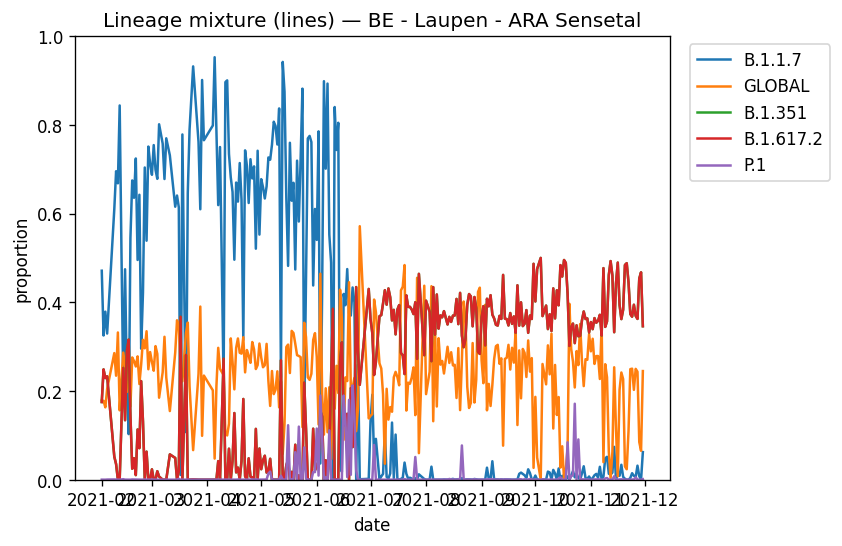

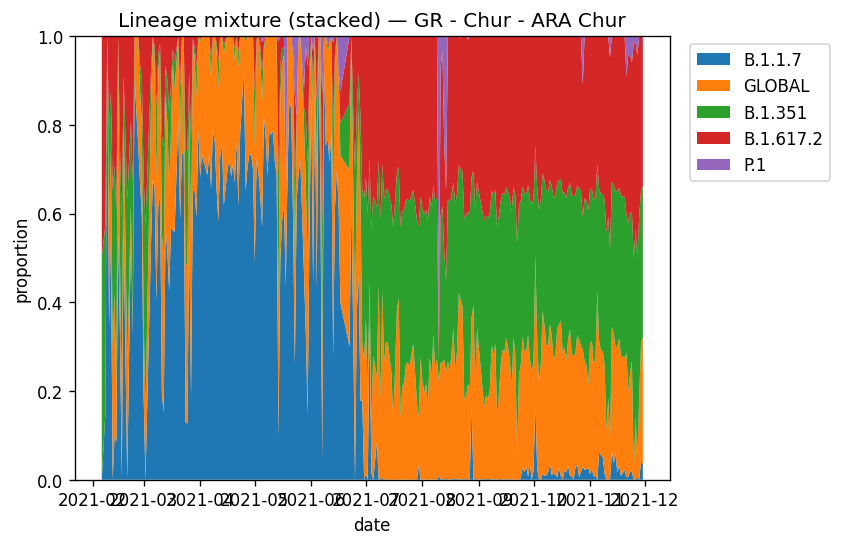

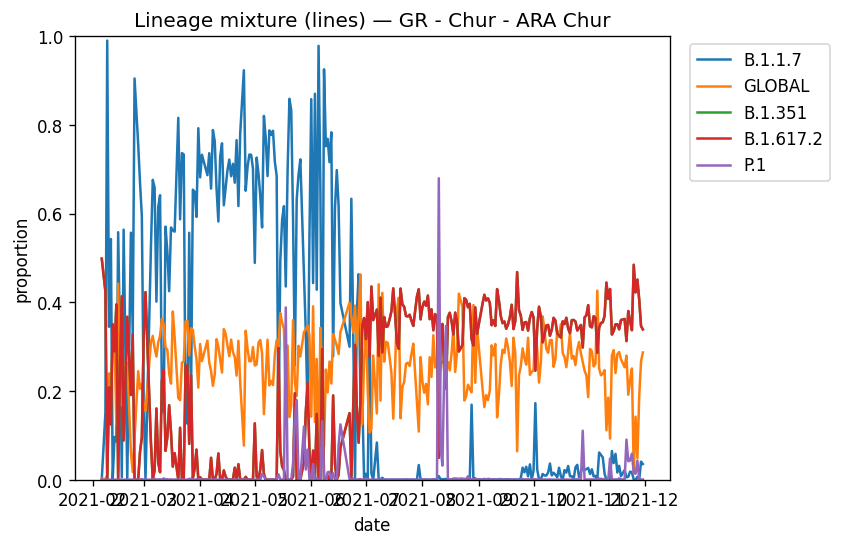

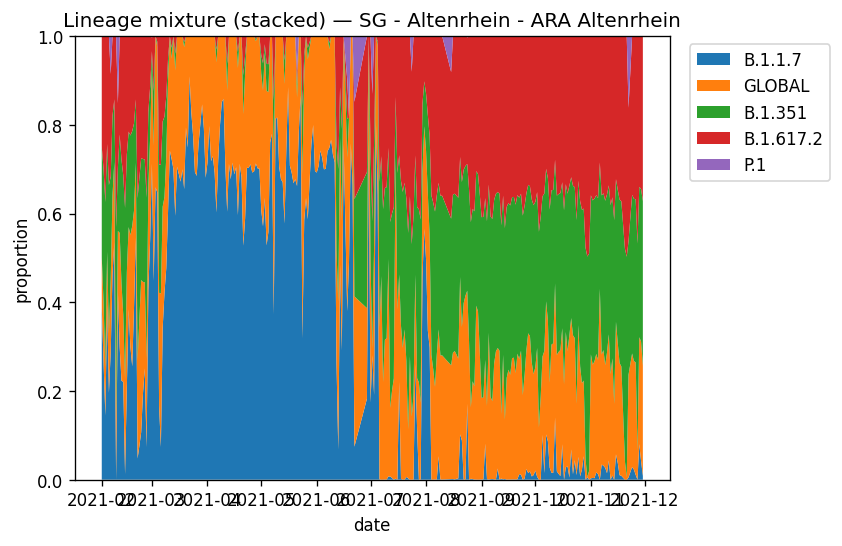

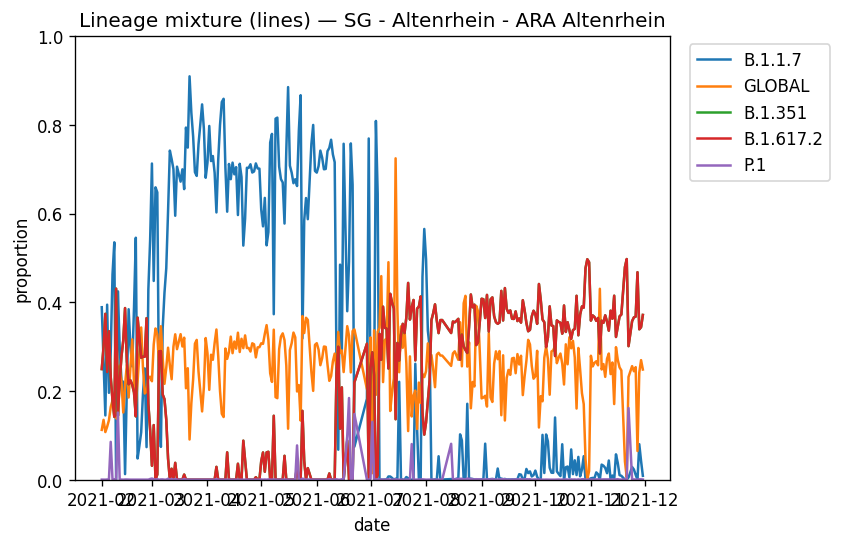

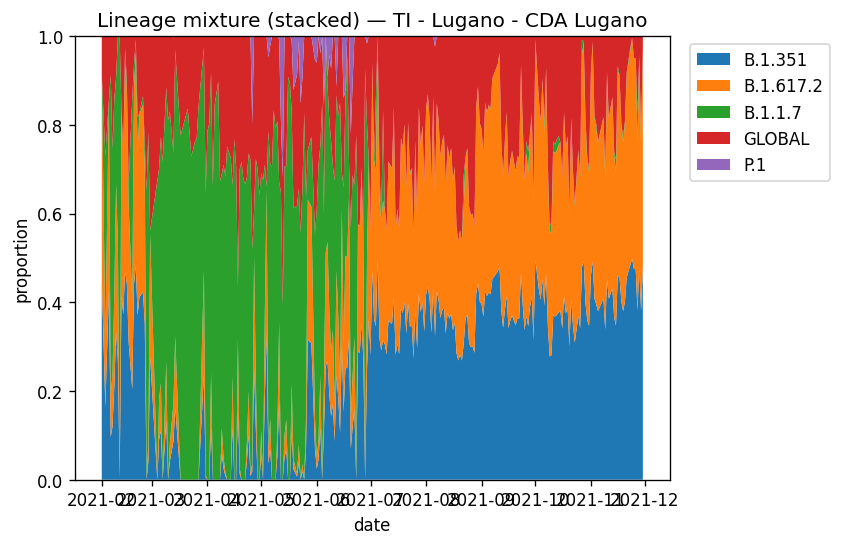

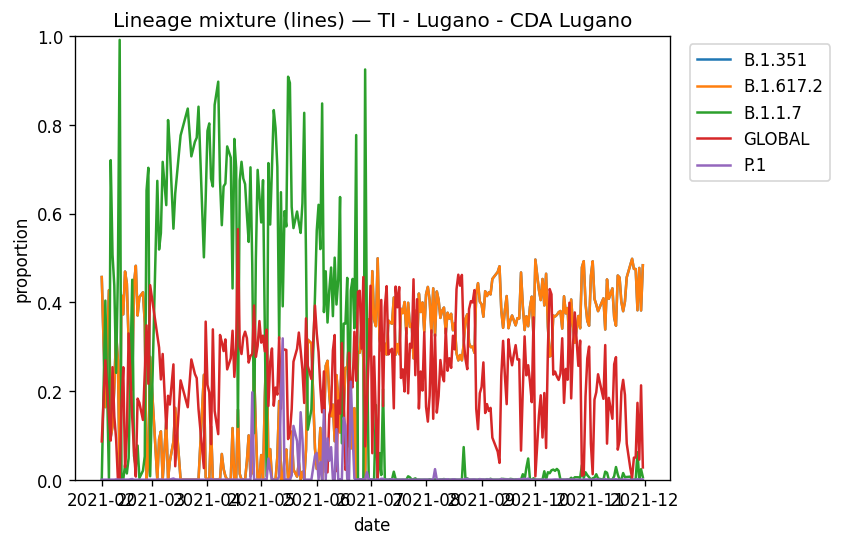

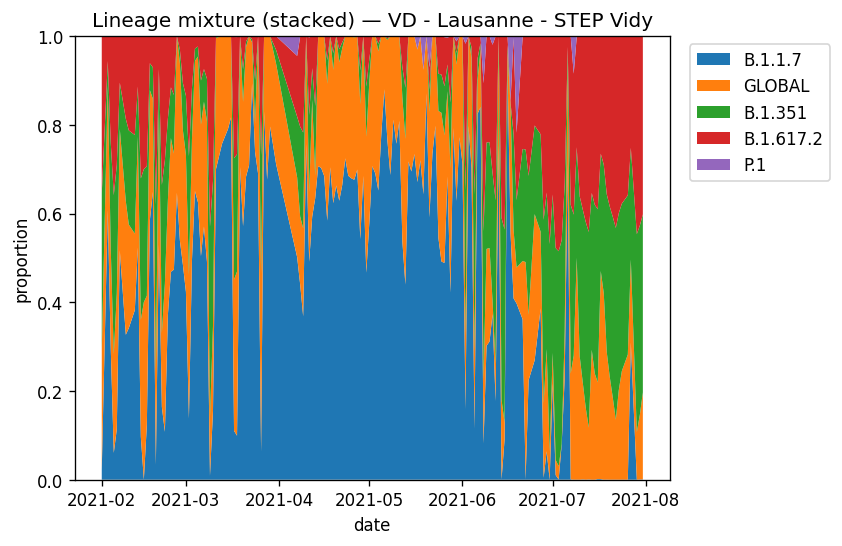

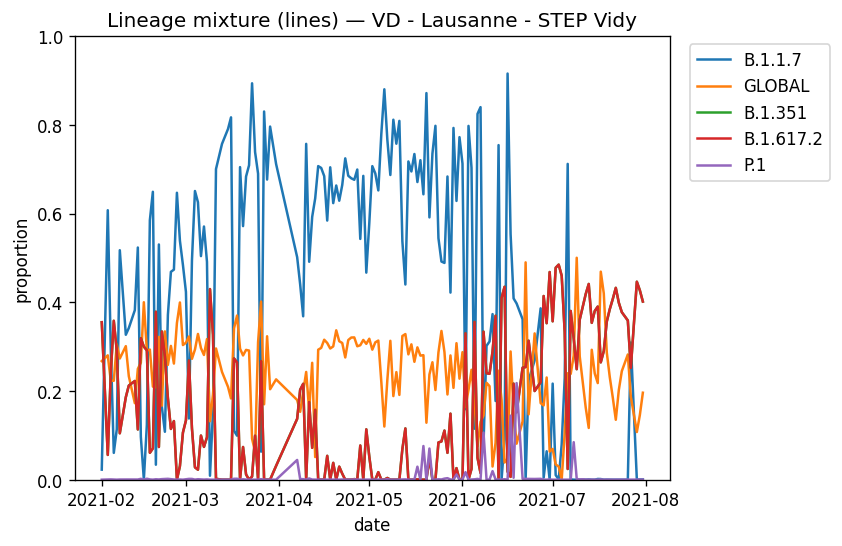

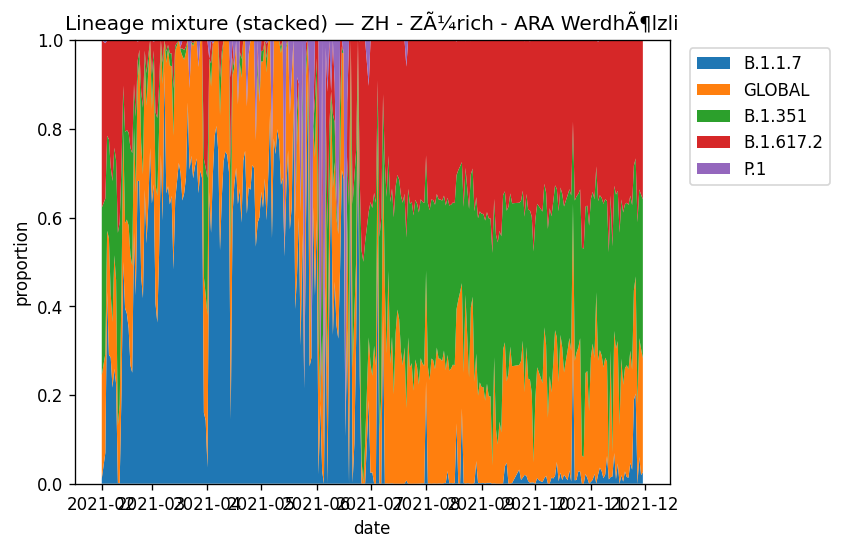

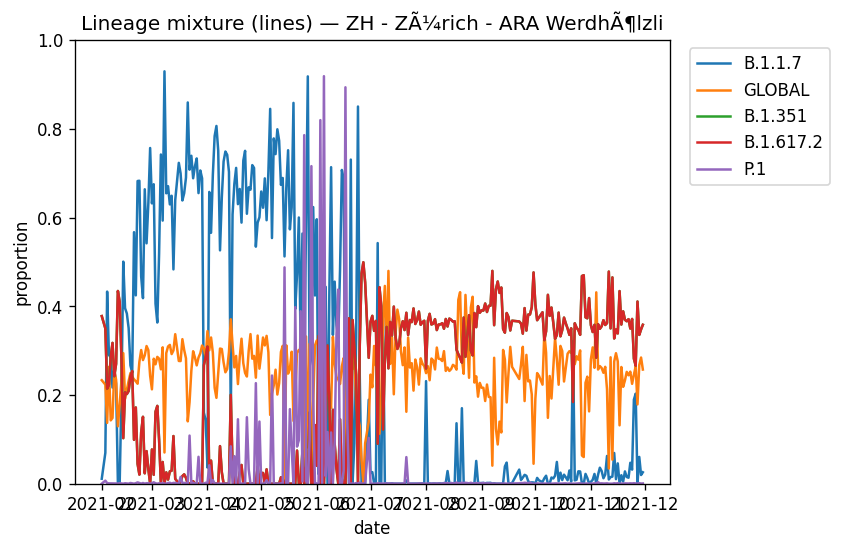

In [15]:

import matplotlib.pyplot as plt

def _plot_site_mixture_stacked(df_site, site, topk=TOP_LINEAGES):
    D = df_site.copy().sort_values('date')
    order = (D.groupby('lineage')['theta'].mean().sort_values(ascending=False).head(topk).index.tolist())
    D = D[D['lineage'].isin(order)]
    P = D.pivot_table(index='date', columns='lineage', values='theta', aggfunc='mean').fillna(0.0).sort_index()
    if P.shape[0]==0: 
        print(f"[{site}] no data."); return
    plt.figure()
    plt.stackplot(P.index.to_pydatetime(), P[order].values.T if order else P.values.T, labels=order)
    plt.ylim(0,1); plt.title(f"Lineage mixture (stacked) — {site}"); plt.xlabel("date"); plt.ylabel("proportion")
    plt.legend(loc='upper left', bbox_to_anchor=(1.02,1.0)); plt.show()

def _plot_site_mixture_lines(df_site, site, topk=TOP_LINEAGES):
    D = df_site.copy().sort_values('date')
    order = (D.groupby('lineage')['theta'].mean().sort_values(ascending=False).head(topk).index.tolist())
    D = D[D['lineage'].isin(order)]
    P = D.pivot_table(index='date', columns='lineage', values='theta', aggfunc='mean').fillna(0.0).sort_index()
    if P.shape[0]==0: 
        print(f"[{site}] no data."); return
    plt.figure()
    for lin in order: plt.plot(P.index.to_pydatetime(), P[lin].to_numpy(), label=str(lin))
    plt.ylim(0,1); plt.title(f"Lineage mixture (lines) — {site}"); plt.xlabel("date"); plt.ylabel("proportion")
    plt.legend(loc='upper left', bbox_to_anchor=(1.02,1.0)); plt.show()

sites = list(theta['site_id'].astype(str).unique())
if SITE_FILTER_REGEX:
    sites = [s for s in sites if re.compile(SITE_FILTER_REGEX).search(s)]
for s in sites[:MAX_SITES_PLOTS]:
    df_site = theta[theta['site_id']==s]
    _plot_site_mixture_stacked(df_site, s, topk=TOP_LINEAGES)
    _plot_site_mixture_lines(df_site, s, topk=TOP_LINEAGES)


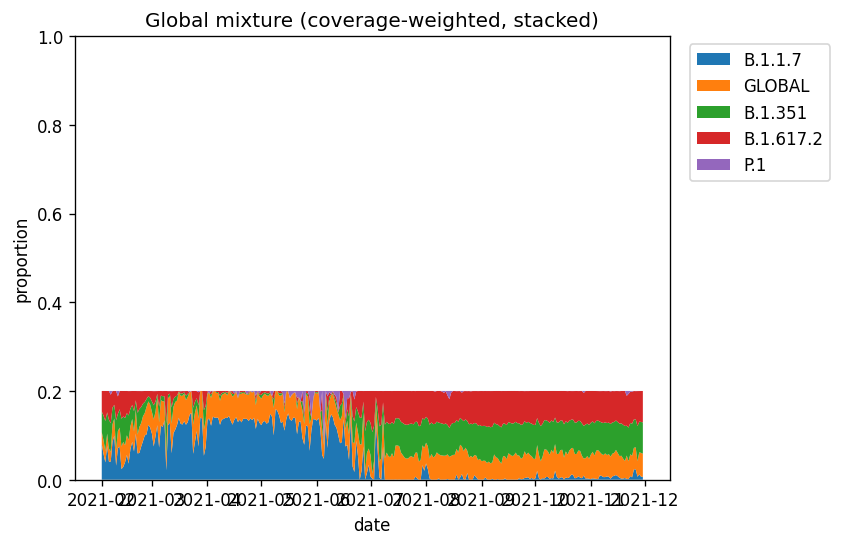

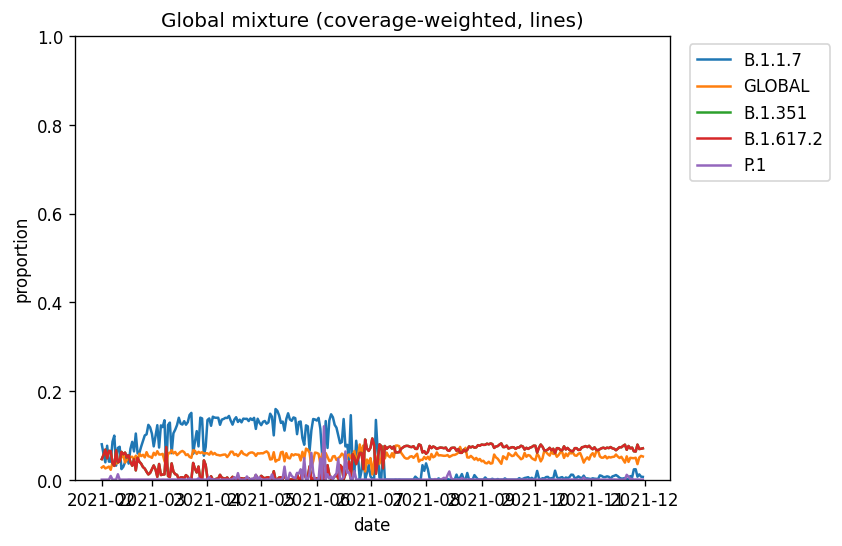

In [16]:

def _global_weighted_theta(theta_df):
    D = theta_df.copy()
    if 'median_coverage' in D.columns:
        w = D[['site_id','date','median_coverage']].drop_duplicates().rename(columns={'median_coverage':'w'})
        D = D.merge(w, on=['site_id','date'], how='left'); D['w'] = D['w'].fillna(1.0)
    else:
        D['w'] = 1.0
    rows=[]
    for dt, G in D.groupby('date', sort=True):
        tmp = G.copy(); tmp['wt'] = tmp['w']*tmp['theta']
        agg = tmp.groupby('lineage')['wt'].sum()/max(tmp['w'].sum(),1e-12)
        for lin, val in agg.items(): rows.append({'date':dt,'lineage':lin,'theta':float(val)})
    return pd.DataFrame(rows)

glob = _global_weighted_theta(theta)
order = glob.groupby('lineage')['theta'].mean().sort_values(ascending=False).head(TOP_LINEAGES).index.tolist()
P = glob[glob['lineage'].isin(order)].pivot_table(index='date', columns='lineage', values='theta', aggfunc='mean').fillna(0.0).sort_index()
if P.shape[0] > 0:
    import matplotlib.pyplot as plt
    plt.figure(); plt.stackplot(P.index.to_pydatetime(), P[order].values.T, labels=order)
    plt.ylim(0,1); plt.title("Global mixture (coverage-weighted, stacked)"); plt.xlabel("date"); plt.ylabel("proportion")
    plt.legend(loc='upper left', bbox_to_anchor=(1.02,1.0)); plt.show()

    plt.figure()
    for lin in order: plt.plot(P.index.to_pydatetime(), P[lin].to_numpy(), label=str(lin))
    plt.ylim(0,1); plt.title("Global mixture (coverage-weighted, lines)"); plt.xlabel("date"); plt.ylabel("proportion")
    plt.legend(loc='upper left', bbox_to_anchor=(1.02,1.0)); plt.show()


,rmse_w
mutation,
AA:S:T19R,0.725064
AA:N:R203M,0.699750
AA:N:D377Y,0.695010
AA:S:L452R,0.657512
AA:S:T478K,0.633016
AA:ORF3A:S26L,0.608728
AA:S:P681R,0.608252
AA:S:D950N,0.606633
AA:M:I82T,0.519580


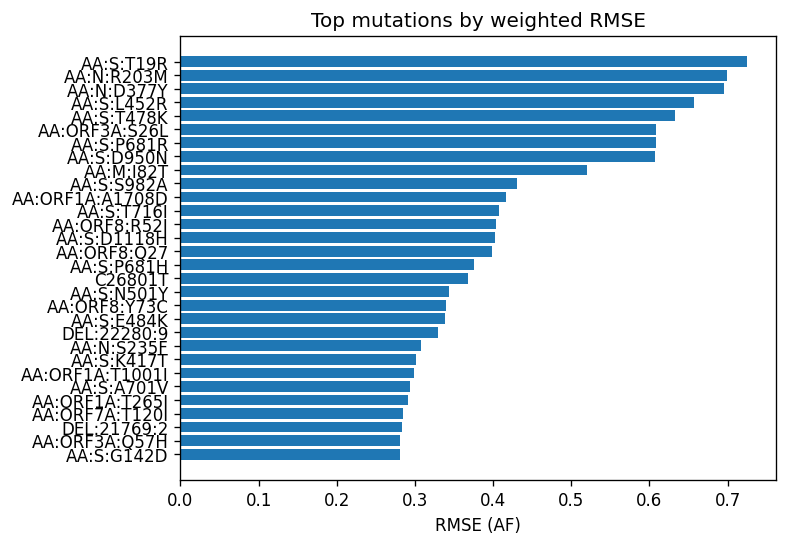

In [17]:

if residuals is not None:
    R = residuals[['mutation','obs_af','pred_af','coverage']].dropna().copy()
    R['sq_w'] = (R['obs_af'] - R['pred_af'])**2 * np.maximum(R['coverage'], 1.0)
    agg = R.groupby('mutation').agg(se_total=('sq_w','sum'), w_total=('coverage','sum'))
    agg['rmse_w'] = np.sqrt(agg['se_total'] / agg['w_total'].clip(lower=1.0))
    top = agg['rmse_w'].sort_values(ascending=False).head(30)
    display(top.to_frame())
    import matplotlib.pyplot as plt
    plt.figure(); plt.barh(list(top.index[::-1]), list(top.values[::-1]))
    plt.title("Top mutations by weighted RMSE"); plt.xlabel("RMSE (AF)"); plt.show()


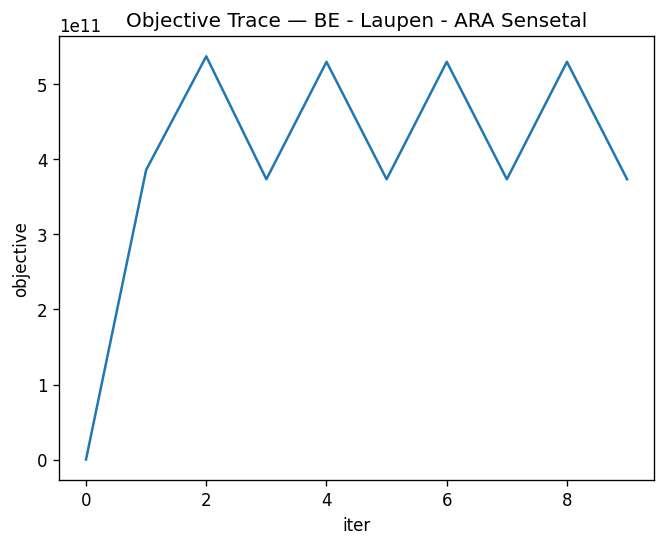

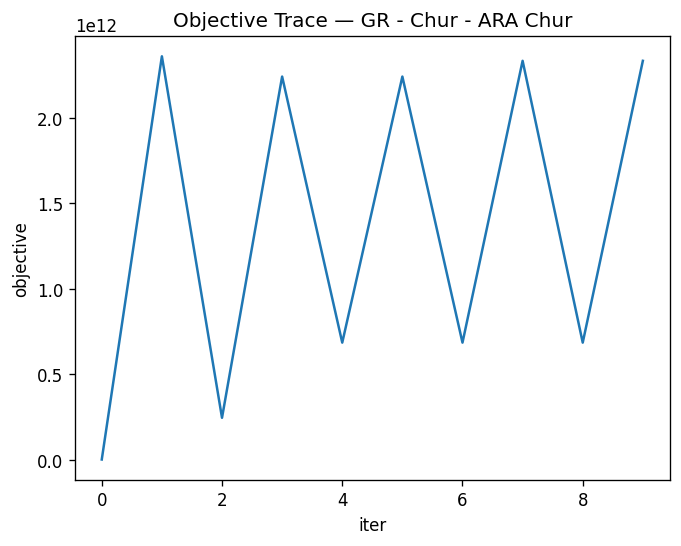

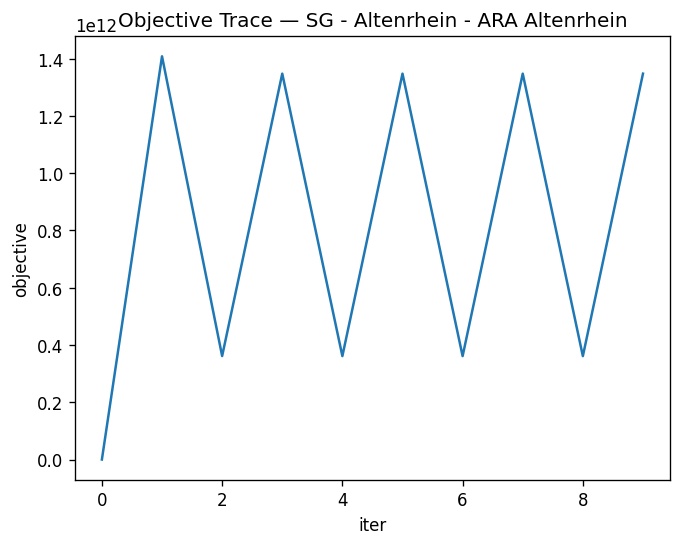

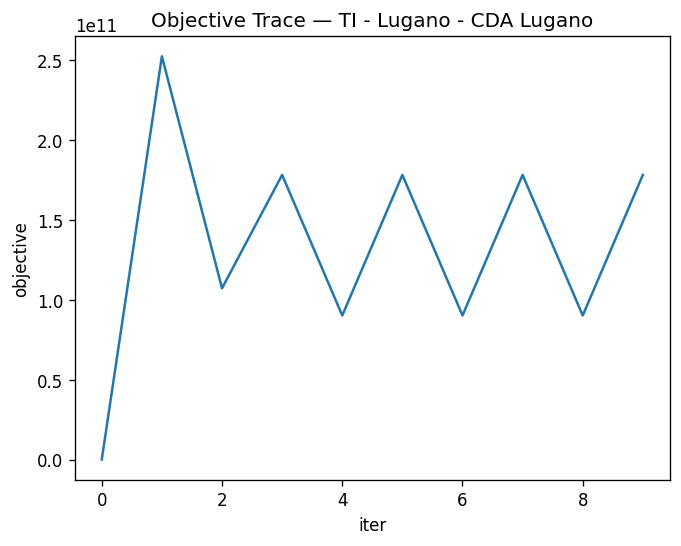

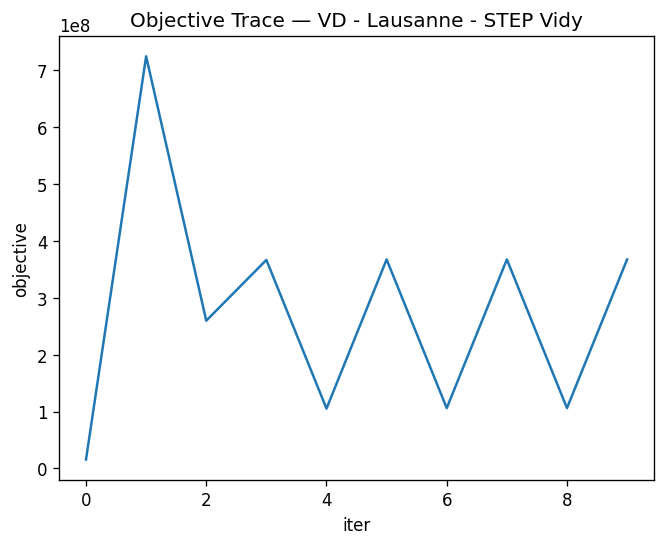

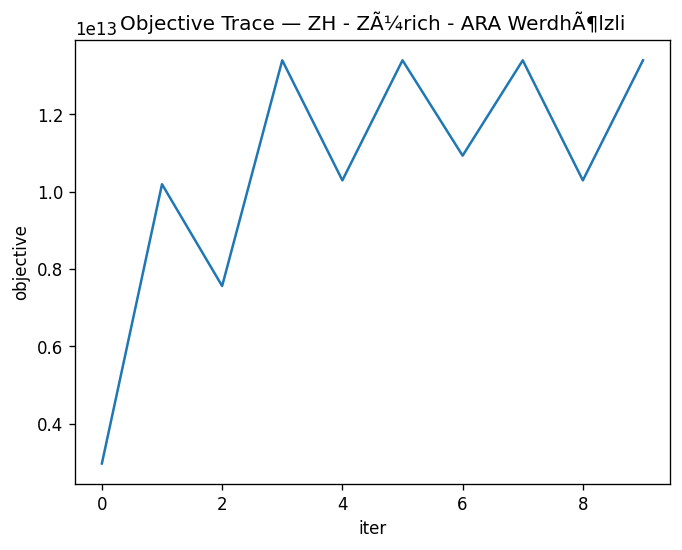

In [18]:

if obj is not None and 'iter' in obj.columns and 'objective' in obj.columns:
    if 'site_id' in obj.columns:
        groups = obj.groupby('site_id', sort=False)
    else:
        groups = [('ALL', obj)]
    for (sid, G) in list(groups)[:MAX_SITES_PLOTS]:
        import matplotlib.pyplot as plt
        plt.figure(); plt.plot(G['iter'].to_numpy(), G['objective'].astype(float).to_numpy())
        plt.title(f"Objective Trace — {sid}"); plt.xlabel("iter"); plt.ylabel("objective"); plt.show()


,site_id,date,entropy
0,BE - Laupen - ARA Sensetal,2021-02-01,0.790968
1,BE - Laupen - ARA Sensetal,2021-02-02,0.847717
2,BE - Laupen - ARA Sensetal,2021-02-03,0.831735
3,BE - Laupen - ARA Sensetal,2021-02-04,0.852199
4,BE - Laupen - ARA Sensetal,2021-02-08,0.602635
5,BE - Laupen - ARA Sensetal,2021-02-09,0.514891
6,BE - Laupen - ARA Sensetal,2021-02-10,0.394845
7,BE - Laupen - ARA Sensetal,2021-02-11,0.269319
8,BE - Laupen - ARA Sensetal,2021-02-12,0.753313
9,BE - Laupen - ARA Sensetal,2021-02-13,0.861693


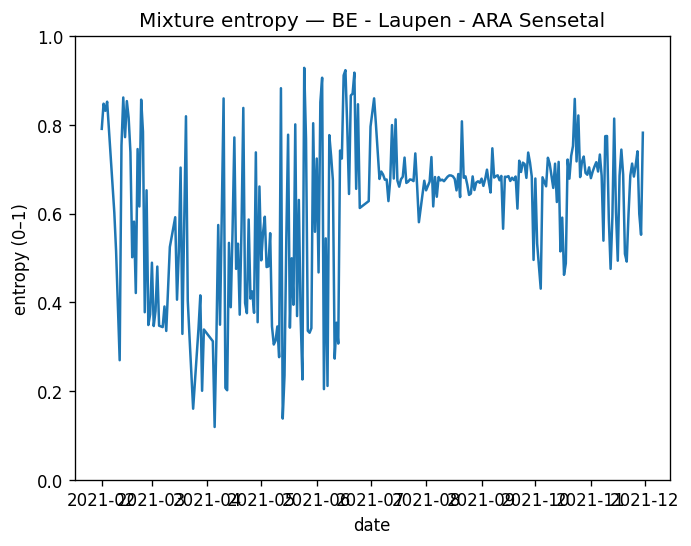

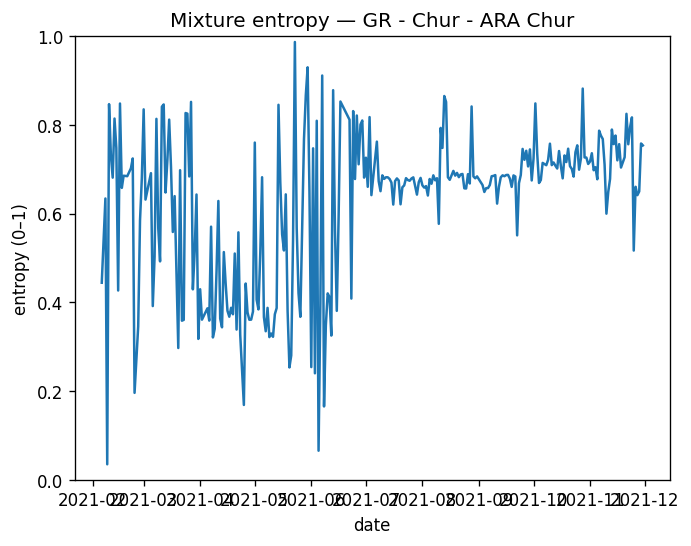

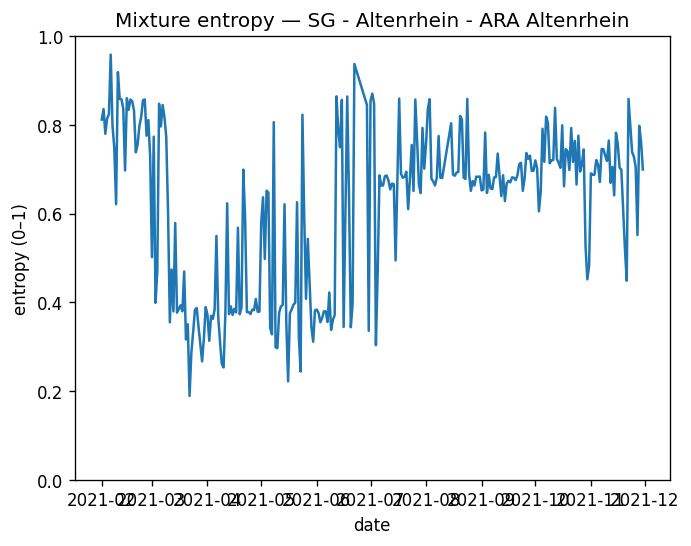

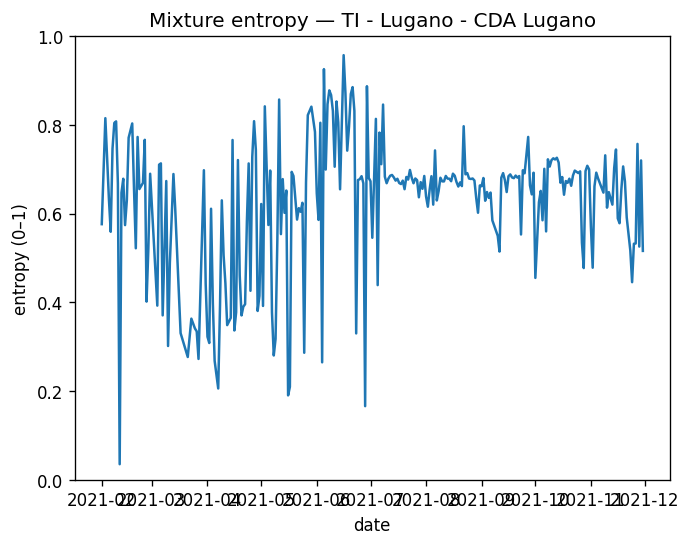

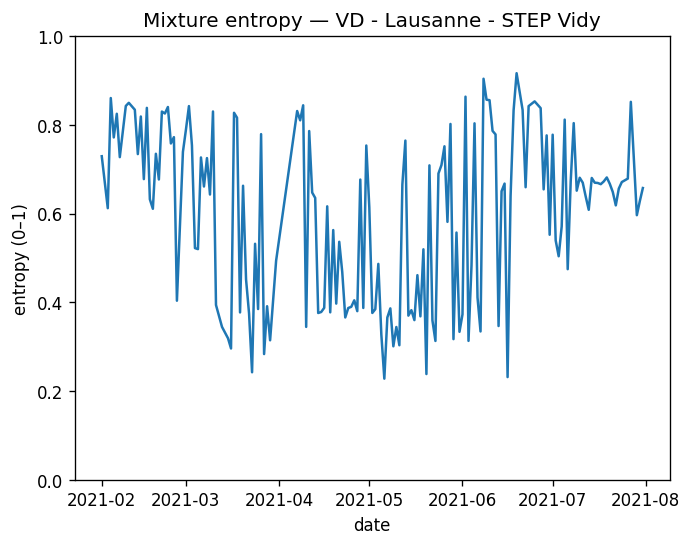

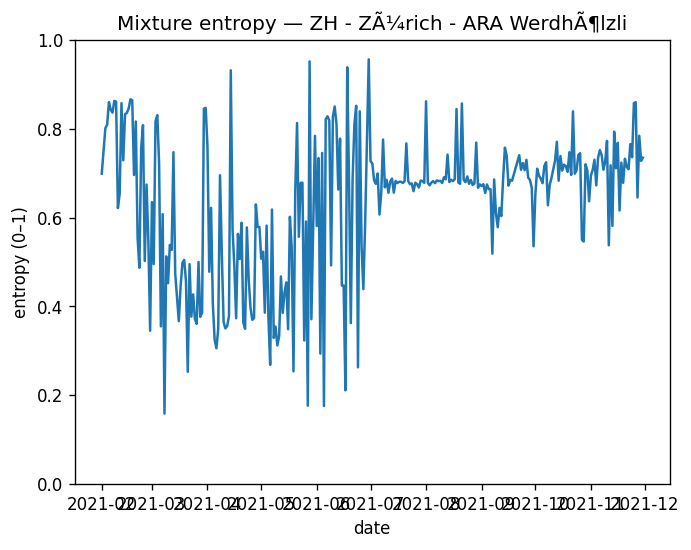

In [19]:

rows = []
for (sid, dt), G in theta.groupby(['site_id','date'], sort=True):
    pivot = G.pivot_table(index='lineage', values='theta', aggfunc='mean').fillna(0.0)
    th = pivot['theta'].to_numpy().clip(1e-12, 1.0)
    H = -np.sum(th*np.log(th)); K = th.size; Hn = (H/np.log(K)) if K>1 else 0.0
    rows.append({'site_id':sid,'date':dt,'entropy':Hn})
entropy_df = pd.DataFrame(rows).sort_values(['site_id','date'])
display(entropy_df.head(12))

for sid, G in list(entropy_df.groupby('site_id', sort=False))[:MAX_SITES_PLOTS]:
    import matplotlib.pyplot as plt
    plt.figure(); plt.plot(pd.to_datetime(G['date']).to_numpy(), G['entropy'].to_numpy())
    plt.ylim(0,1); plt.title(f"Mixture entropy — {sid}"); plt.xlabel("date"); plt.ylabel("entropy (0–1)"); plt.show()


In [20]:

prev_site = (theta.groupby(['site_id','lineage'])['theta'].mean().reset_index().rename(columns={'theta':'mean_theta'}))
if 'median_coverage' in theta.columns:
    w = theta[['site_id','date','median_coverage']].drop_duplicates().rename(columns={'median_coverage':'w'})
    T = theta.merge(w, on=['site_id','date'], how='left')
    T['wt'] = T['theta'] * T['w'].fillna(1.0)
    prev_global = (T.groupby('lineage')['wt'].sum() / T['w'].fillna(1.0).sum()).reset_index()
    prev_global.columns = ['lineage','mean_theta']
else:
    prev_global = theta.groupby('lineage')['theta'].mean().reset_index().rename(columns={'theta':'mean_theta'})
_display_df(prev_site, "lineage_prevalence_by_site")
_display_df(prev_global, "lineage_prevalence_global")


\n>>> lineage_prevalence_by_site (head)


,site_id,lineage,mean_theta
0,BE - Laupen - ARA Sensetal,B.1.1.7,0.284378
1,BE - Laupen - ARA Sensetal,B.1.351,0.235058
2,BE - Laupen - ARA Sensetal,B.1.617.2,0.235058
3,BE - Laupen - ARA Sensetal,GLOBAL,0.236397
4,BE - Laupen - ARA Sensetal,P.1,0.009110
5,GR - Chur - ARA Chur,B.1.1.7,0.265944
6,GR - Chur - ARA Chur,B.1.351,0.231401
7,GR - Chur - ARA Chur,B.1.617.2,0.231401
8,GR - Chur - ARA Chur,GLOBAL,0.259205
9,GR - Chur - ARA Chur,P.1,0.012050


\n>>> lineage_prevalence_global (head)


,lineage,mean_theta
0,B.1.1.7,0.028319
1,B.1.351,0.058862
2,B.1.617.2,0.058862
3,GLOBAL,0.052862
4,P.1,0.001094


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


✅ Advanced plotting helpers loaded. You can now call:
• plot_lineage_mixture_smooth(df_site, 'SITE_X')
• plot_residual_density(residuals)
• plot_entropy_trend(entropy_df, 'SITE_X')
• plot_residuals_violin(residuals)
• plot_site_dashboard('SITE_X', theta, residuals, entropy)


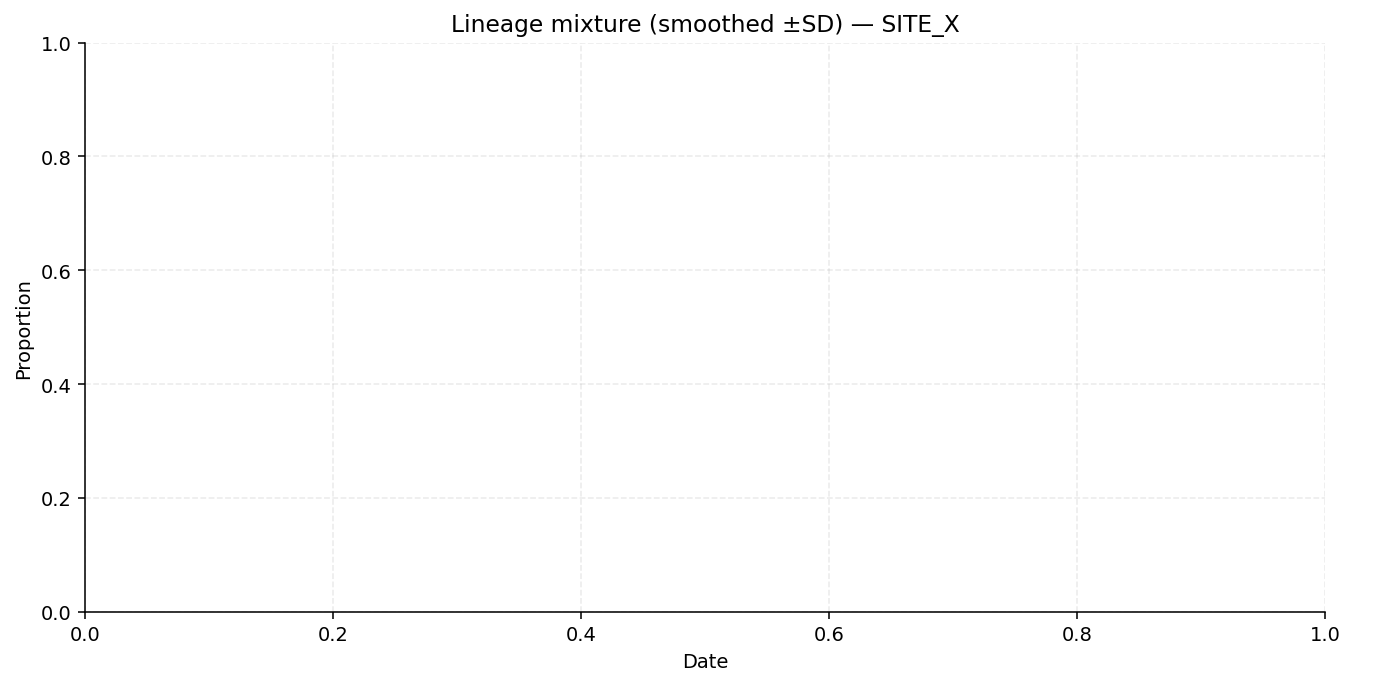

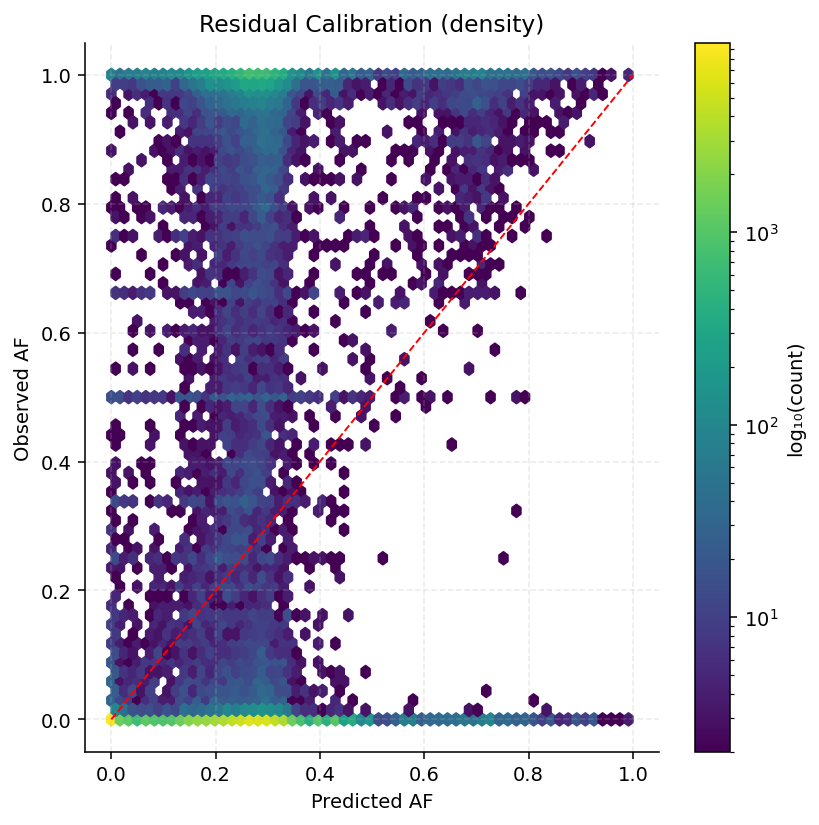

C:\Users\osoom\AppData\Local\Temp\ipykernel_20068\3500405502.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = df.groupby("coverage_q")["residual"].apply(list)


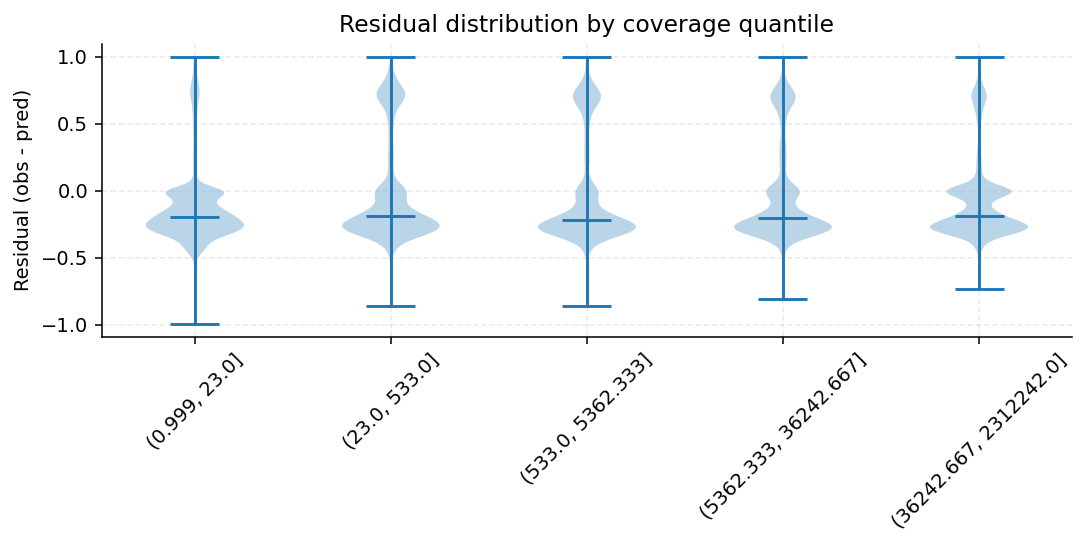

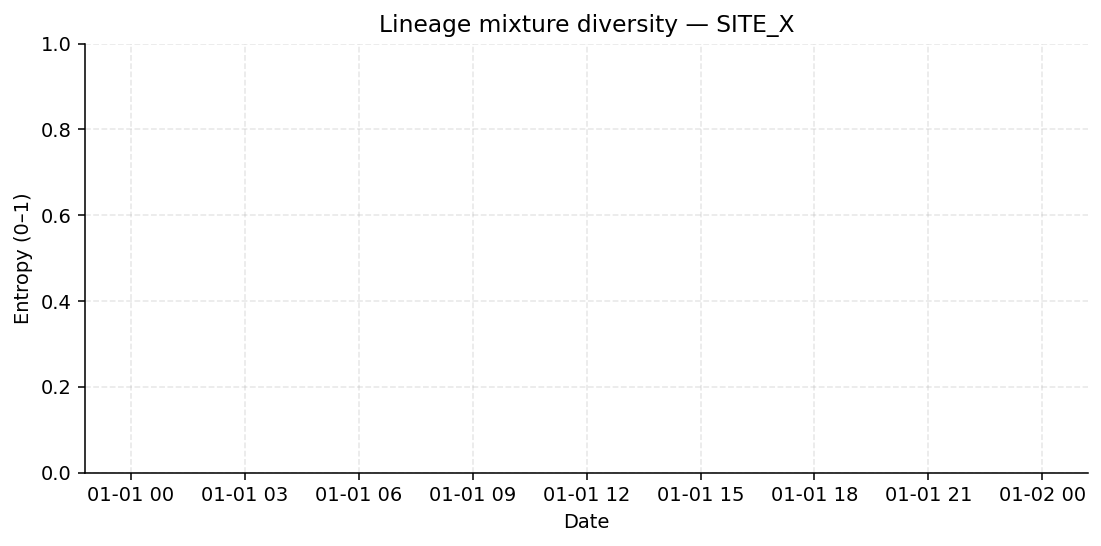

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


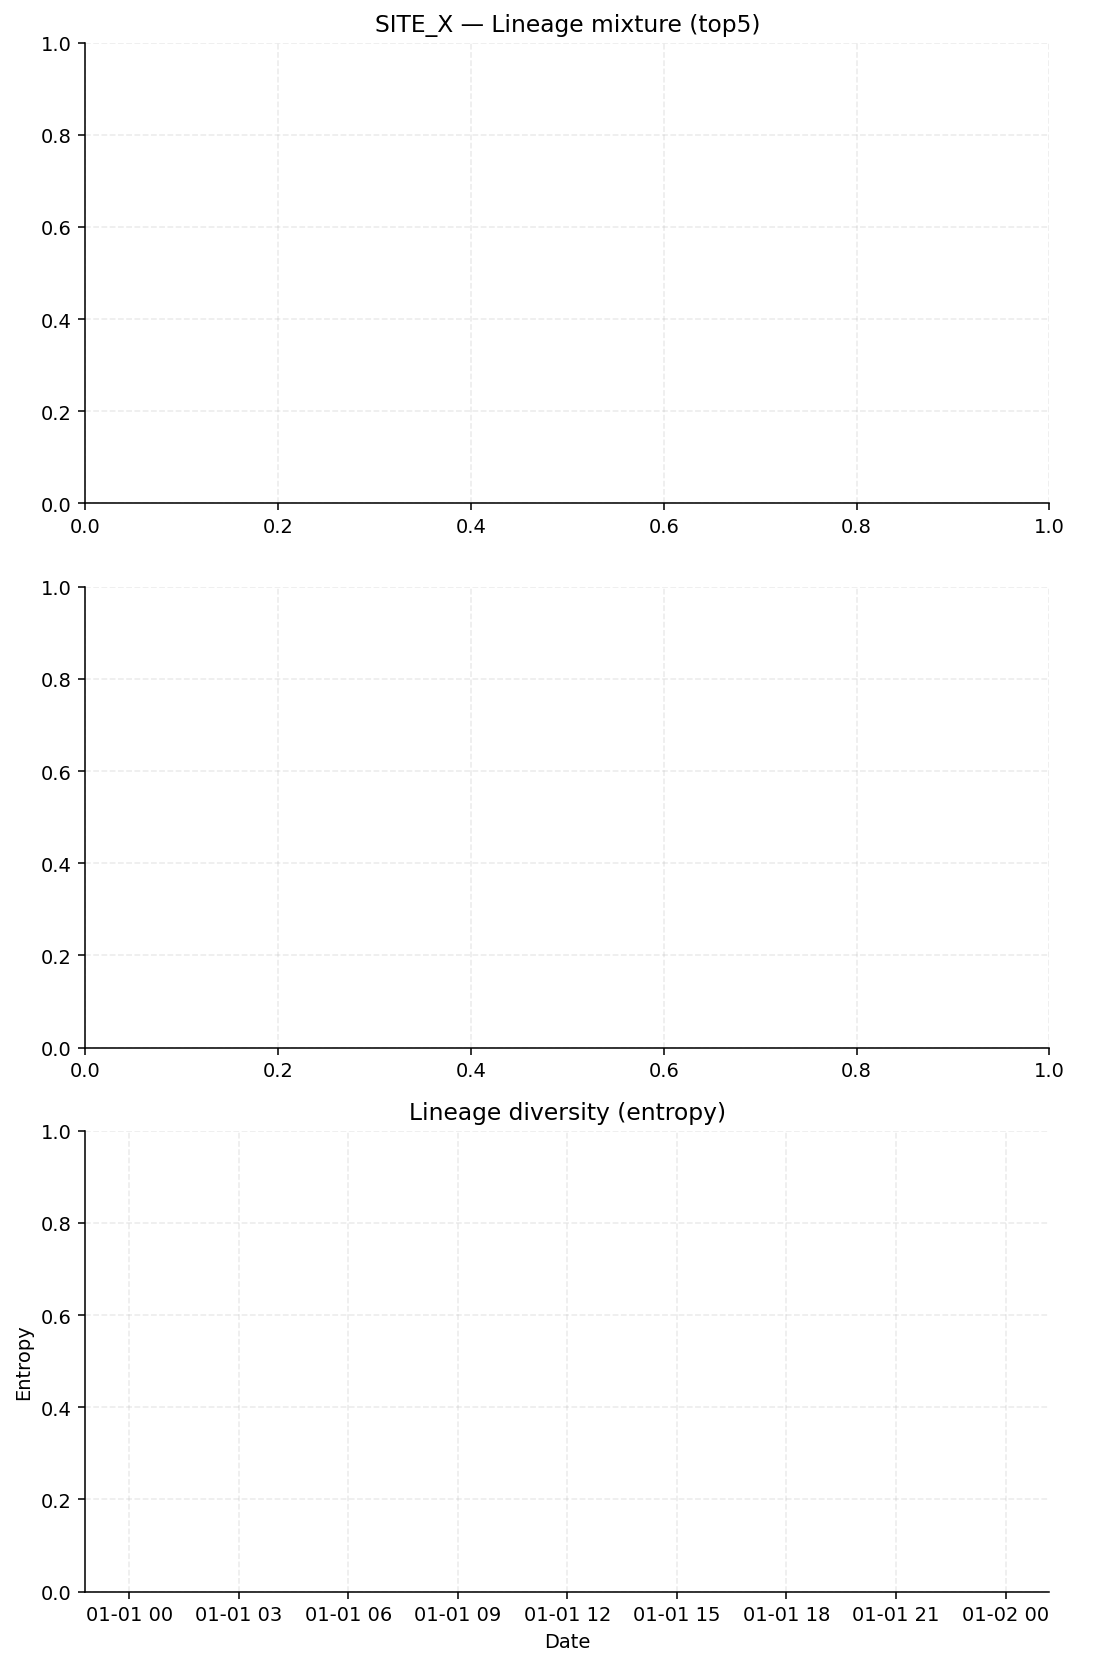

In [22]:
# =====================================================================
# Advanced plotting and visualization helpers for likelihood analysis
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.frameon": False
})

# ---------------------------------------------------------------
# 1. Smoothed lineage mixture plot with credible ribbons
# ---------------------------------------------------------------
def plot_lineage_mixture_smooth(df_site, site, topk=8, theta_unc=None, smooth=True, bandwidth_days=7):
    """
    Plot lineage mixtures with optional smoothing and ±SD ribbons.
    df_site: DataFrame [date, lineage, theta]
    theta_unc: optional DataFrame with 'site_id', 'date', 'lineage', 'theta_sd'
    """
    D = df_site.copy().sort_values("date")
    order = (
        D.groupby("lineage")["theta"]
        .mean()
        .sort_values(ascending=False)
        .head(topk)
        .index.tolist()
    )
    P = (
        D[D["lineage"].isin(order)]
        .pivot_table(index="date", columns="lineage", values="theta", aggfunc="mean")
        .fillna(0.0)
        .sort_index()
    )

    # optional temporal smoothing (rolling window in days)
    if smooth and len(P) > 3:
        win = max(1, int(bandwidth_days))
        P = P.rolling(window=win, min_periods=1, center=True).mean()

    plt.figure(figsize=(10, 5))
    for lin in order:
        y = P[lin].to_numpy()
        plt.plot(P.index, y, lw=2, label=str(lin))
        # credible band if available
        if theta_unc is not None and "theta_sd" in theta_unc.columns:
            unc = (
                theta_unc.query("site_id == @site and lineage == @lin")
                .set_index("date")["theta_sd"]
                .reindex(P.index)
                .fillna(method="ffill")
                .to_numpy()
            )
            plt.fill_between(
                P.index,
                np.clip(y - unc, 0, 1),
                np.clip(y + unc, 0, 1),
                alpha=0.25
            )
    plt.ylim(0, 1)
    plt.title(f"Lineage mixture (smoothed ±SD) — {site}")
    plt.xlabel("Date")
    plt.ylabel("Proportion")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------
# 2. Residual calibration scatter with density and identity line
# ---------------------------------------------------------------
def plot_residual_density(residuals, title="Residual Calibration (density)"):
    """Plots observed vs predicted AF with density shading + identity line."""
    if residuals is None or residuals.empty:
        print("No residuals provided.")
        return
    r = residuals[["obs_af", "pred_af", "coverage"]].dropna().copy()
    r = r.sample(min(len(r), 200_000), random_state=42)
    plt.figure(figsize=(6, 6))
    hb = plt.hexbin(
        r["pred_af"], r["obs_af"], gridsize=60, cmap="viridis", bins="log", mincnt=2
    )
    cb = plt.colorbar(hb)
    cb.set_label("log₁₀(count)")
    plt.plot([0, 1], [0, 1], "r--", lw=1)
    plt.xlabel("Predicted AF")
    plt.ylabel("Observed AF")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------
# 3. Entropy / diversity plot (smoothed)
# ---------------------------------------------------------------
def plot_entropy_trend(entropy_df, site, smooth=True, window=3):
    """
    Plot entropy over time for a site with optional smoothing.
    """
    if entropy_df is None or entropy_df.empty:
        print("No entropy data provided.")
        return
    E = entropy_df[entropy_df["site_id"] == site].sort_values("date").copy()
    if smooth and len(E) > window:
        E["entropy_smooth"] = E["entropy"].rolling(window, center=True).mean()
    else:
        E["entropy_smooth"] = E["entropy"]
    plt.figure(figsize=(8, 4))
    plt.plot(E["date"], E["entropy_smooth"], color="tab:blue", lw=2)
    plt.ylim(0, 1)
    plt.xlabel("Date")
    plt.ylabel("Entropy (0–1)")
    plt.title(f"Lineage mixture diversity — {site}")
    plt.grid(True, ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------
# 4. Coverage vs residuals violin plot (distributional diagnostic)
# ---------------------------------------------------------------
def plot_residuals_violin(residuals):
    """Visualize residual distribution across coverage quantiles."""
    if residuals is None or residuals.empty:
        print("No residuals provided.")
        return
    df = residuals.copy()
    df["coverage_q"] = pd.qcut(df["coverage"].clip(lower=1.0), q=6, duplicates="drop")
    groups = df.groupby("coverage_q")["residual"].apply(list)
    plt.figure(figsize=(8, 4))
    plt.violinplot(groups, showmedians=True)
    plt.xticks(np.arange(1, len(groups) + 1), [str(x) for x in groups.index], rotation=45)
    plt.ylabel("Residual (obs - pred)")
    plt.title("Residual distribution by coverage quantile")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------
# 5. Site summary multipanel dashboard
# ---------------------------------------------------------------
def plot_site_dashboard(site_id, theta, residuals=None, entropy=None, theta_unc=None):
    """Creates a 3x1 dashboard: mixture (lines), residuals density, entropy."""
    fig, axs = plt.subplots(3, 1, figsize=(8, 12))
    df_site = theta.query("site_id == @site_id").sort_values("date").copy()
    order = (
        df_site.groupby("lineage")["theta"]
        .mean()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )
    P = (
        df_site[df_site["lineage"].isin(order)]
        .pivot_table(index="date", columns="lineage", values="theta", aggfunc="mean")
        .fillna(0.0)
        .sort_index()
    )

    # 1. Mixture lines
    for lin in order:
        axs[0].plot(P.index, P[lin], lw=2, label=lin)
    axs[0].set_ylim(0, 1)
    axs[0].set_title(f"{site_id} — Lineage mixture (top5)")
    axs[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1))

    # 2. Residuals density
    if residuals is not None:
        r = residuals[residuals["site_id"] == site_id]
        if not r.empty:
            hb = axs[1].hexbin(
                r["pred_af"],
                r["obs_af"],
                gridsize=45,
                bins="log",
                cmap="viridis",
                mincnt=2,
            )
            axs[1].plot([0, 1], [0, 1], "r--")
            axs[1].set_xlabel("Predicted AF")
            axs[1].set_ylabel("Observed AF")
            axs[1].set_title("Calibration (obs vs pred)")
    # 3. Entropy
    if entropy is not None:
        E = entropy[entropy["site_id"] == site_id].sort_values("date")
        axs[2].plot(E["date"], E["entropy"], lw=2)
        axs[2].set_ylim(0, 1)
        axs[2].set_xlabel("Date")
        axs[2].set_ylabel("Entropy")
        axs[2].set_title("Lineage diversity (entropy)")

    plt.tight_layout()
    plt.show()

print("✅ Advanced plotting helpers loaded. You can now call:")
print("• plot_lineage_mixture_smooth(df_site, 'SITE_X')")
print("• plot_residual_density(residuals)")
print("• plot_entropy_trend(entropy_df, 'SITE_X')")
print("• plot_residuals_violin(residuals)")
print("• plot_site_dashboard('SITE_X', theta, residuals, entropy)")
# Smoothed lineage mixture with credible bands
plot_lineage_mixture_smooth(
    theta.query("site_id == 'SITE_X'"),
    site="SITE_X",
    theta_unc=theta_unc,
    smooth=True
)

# Global residual density plot
plot_residual_density(residuals)

# Residual distribution by coverage quantiles
plot_residuals_violin(residuals)

# Entropy trend for one site
plot_entropy_trend(entropy_df, site="SITE_X")

# Complete dashboard per site
plot_site_dashboard("SITE_X", theta, residuals, entropy_df, theta_unc)


In [26]:
def plot_entropy_derivative(entropy_df, site):
    df = entropy_df.query("site_id == @site").sort_values("date").copy()
    if len(df)<3: return
    df["dH/dt"] = np.gradient(df["entropy"].to_numpy())
    plt.figure(figsize=(8,4))
    plt.plot(df["date"], df["dH/dt"], color="tab:orange")
    plt.axhline(0, color="black", lw=0.8)
    plt.title(f"Entropy derivative (volatility) — {site}")
    plt.ylabel("ΔEntropy / Δt")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()
def plot_lineage_correlation(theta, site, topk=10):
    df = theta.query("site_id == @site").copy()
    order = df.groupby("lineage")["theta"].mean().sort_values(ascending=False).head(topk).index
    P = df[df["lineage"].isin(order)].pivot_table(index="date", columns="lineage", values="theta", aggfunc="mean").fillna(0.0)
    C = P.corr()
    plt.figure(figsize=(7,6))
    plt.imshow(C, cmap="coolwarm", vmin=-1, vmax=1)
    plt.xticks(np.arange(len(C)), C.columns, rotation=45)
    plt.yticks(np.arange(len(C)), C.columns)
    plt.title(f"Lineage correlation matrix — {site}")
    plt.colorbar(label="Pearson r")
    plt.tight_layout()
    plt.show()
def plot_leverage_vs_entropy(mutation_leverage, entropy_df):
    if mutation_leverage is None or mutation_leverage.empty:
        print("mutation_leverage.csv not found.")
        return
    L = mutation_leverage.copy()
    E = entropy_df.groupby("site_id")["entropy"].mean().rename("mean_entropy")
    L = L.merge(E, on="site_id", how="left")
    plt.figure(figsize=(6,4))
    plt.scatter(L["mean_entropy"], L["leverage"], alpha=0.7)
    plt.xlabel("Mean mixture entropy")
    plt.ylabel("Mutation leverage")
    plt.title("Mutation leverage vs lineage diversity")
    plt.tight_layout()
    plt.show()
def plot_kappa_entropy_phase(kappa_profile, entropy_df):
    if kappa_profile is None or kappa_profile.empty: 
        print("No kappa_profile found.")
        return
    K = kappa_profile.groupby(["site_id","date"])["kappa"].mean().reset_index()
    M = entropy_df.groupby(["site_id","date"])["entropy"].mean().reset_index()
    J = K.merge(M, on=["site_id","date"], how="inner")
    plt.figure(figsize=(6,6))
    plt.scatter(J["entropy"], np.log10(J["kappa"].clip(lower=1e-3)), alpha=0.5)
    plt.xlabel("Entropy (0–1)")
    plt.ylabel("log10(κ)")
    plt.title("Kappa–Entropy phase space (confidence vs diversity)")
    plt.tight_layout()
    plt.show()


Analyzing site: BE - Laupen - ARA Sensetal


C:\Users\osoom\AppData\Local\Temp\ipykernel_20068\3500405502.py:58: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\osoom\AppData\Local\Temp\ipykernel_20068\3500405502.py:58: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\osoom\AppData\Local\Temp\ipykernel_20068\3500405502.py:58: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\osoom\AppData\Local\Temp\ipykernel_20068\3500405502.py:58: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\osoom\AppData\Local\Temp\ipykernel_20068\3500405502.py:58: FutureWarning: Series.fi

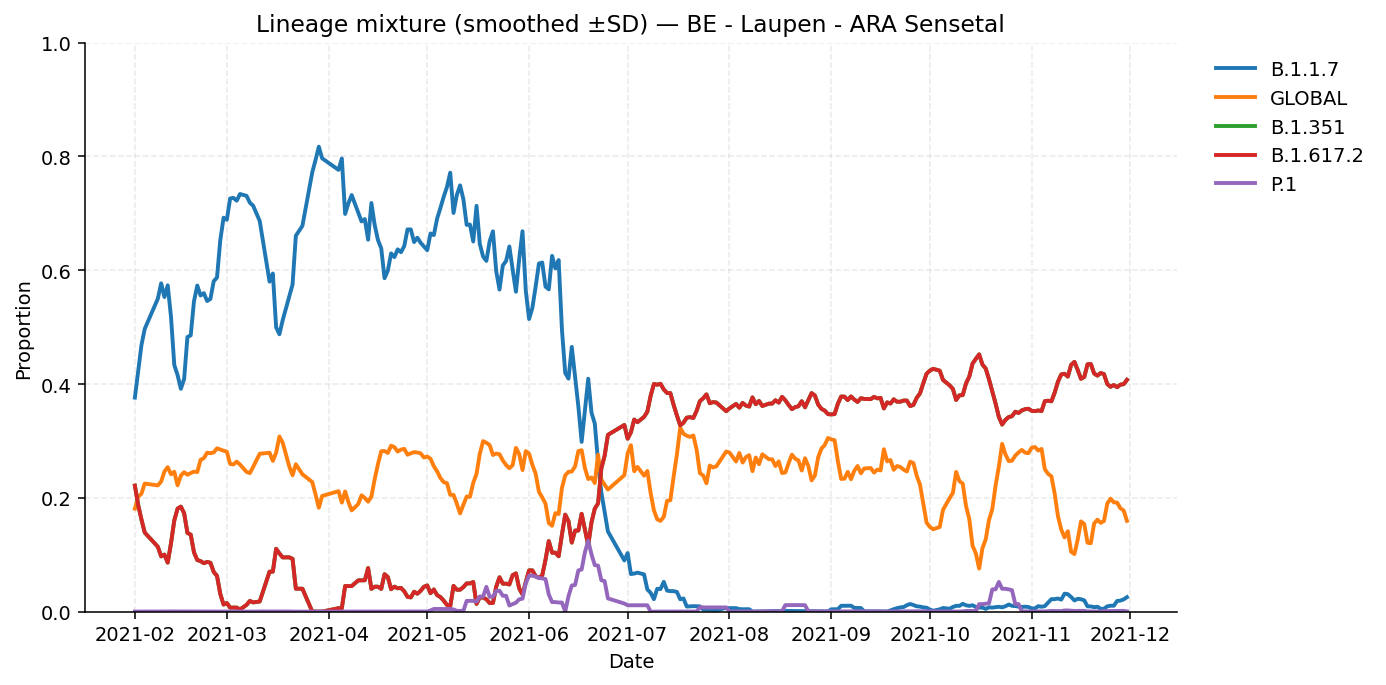

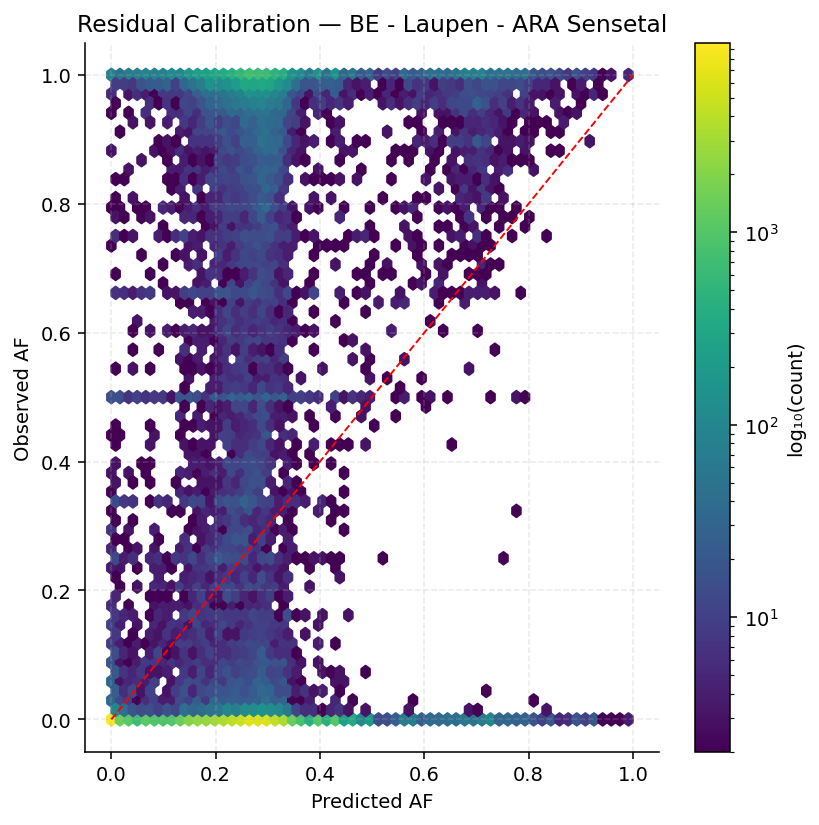

C:\Users\osoom\AppData\Local\Temp\ipykernel_20068\3500405502.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = df.groupby("coverage_q")["residual"].apply(list)


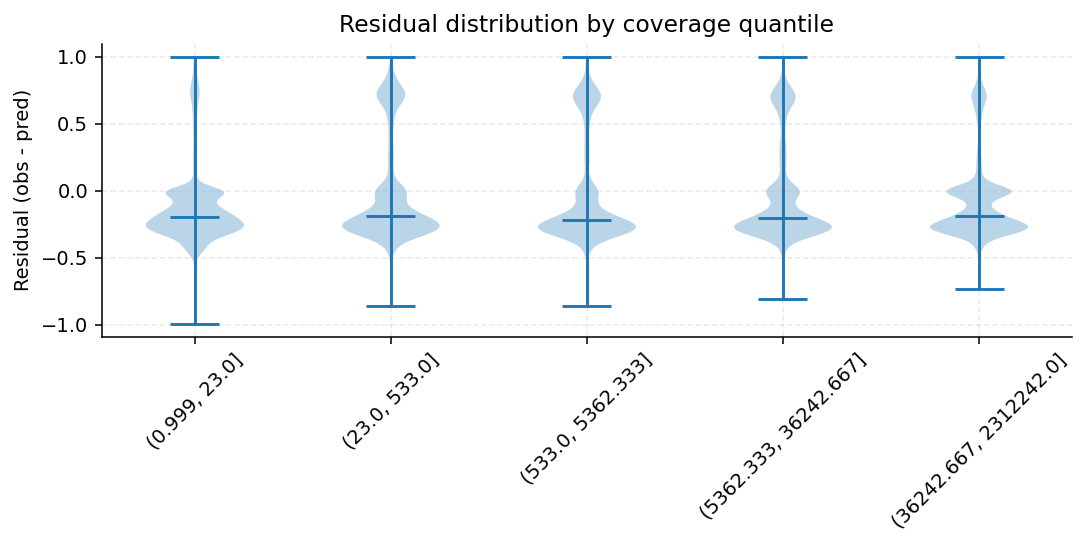

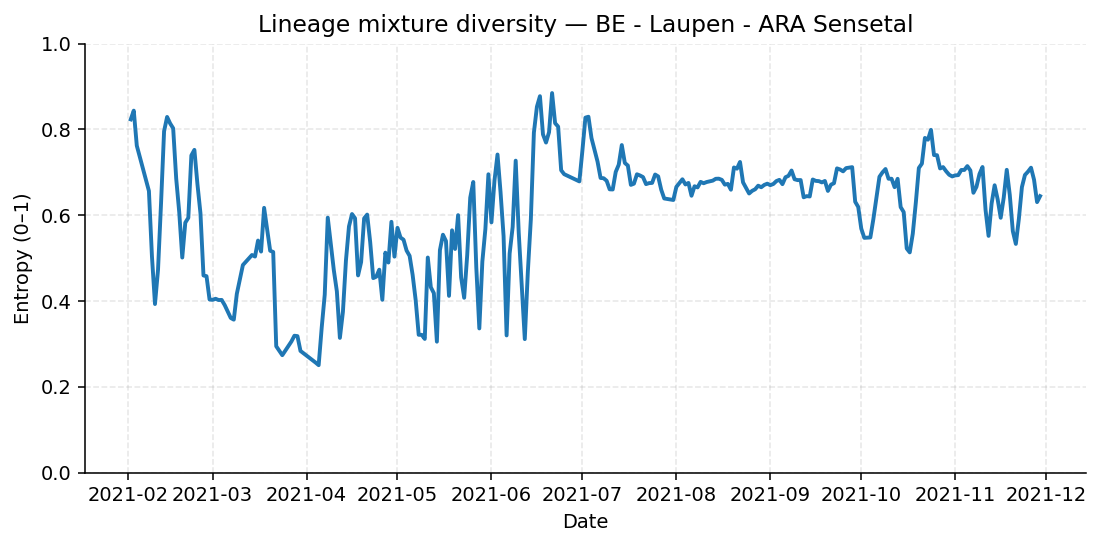

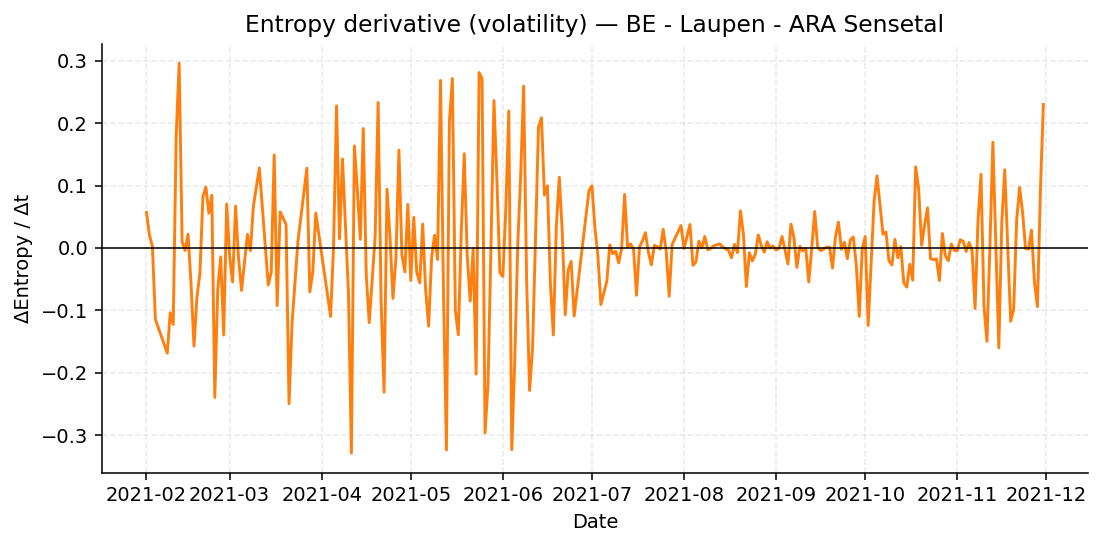

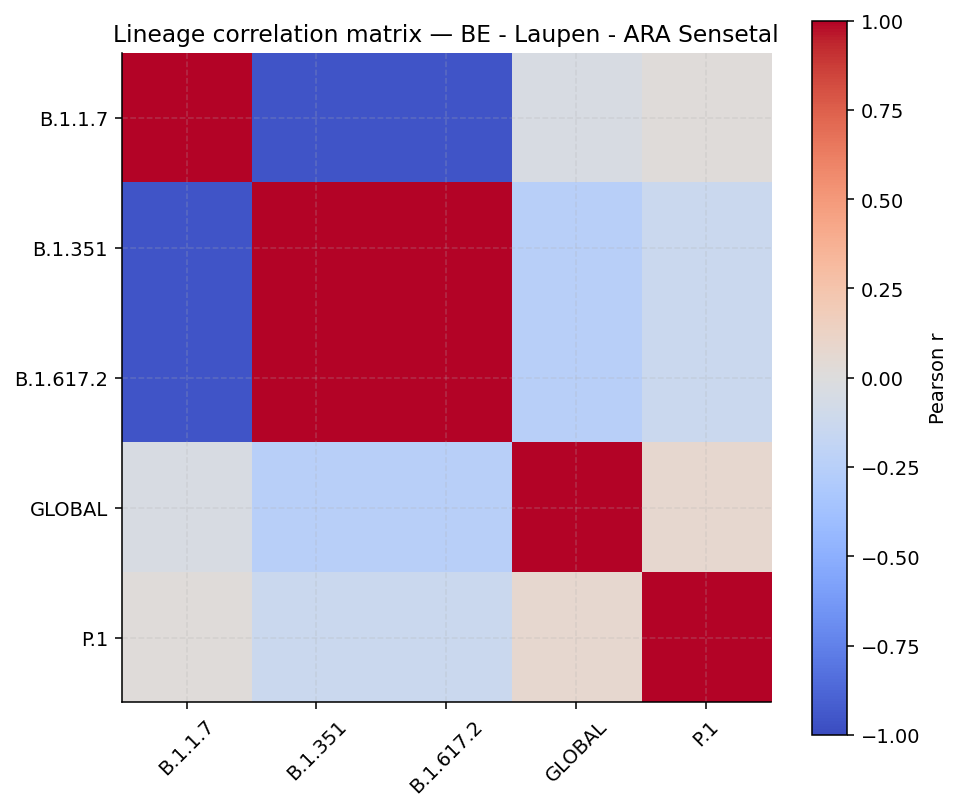

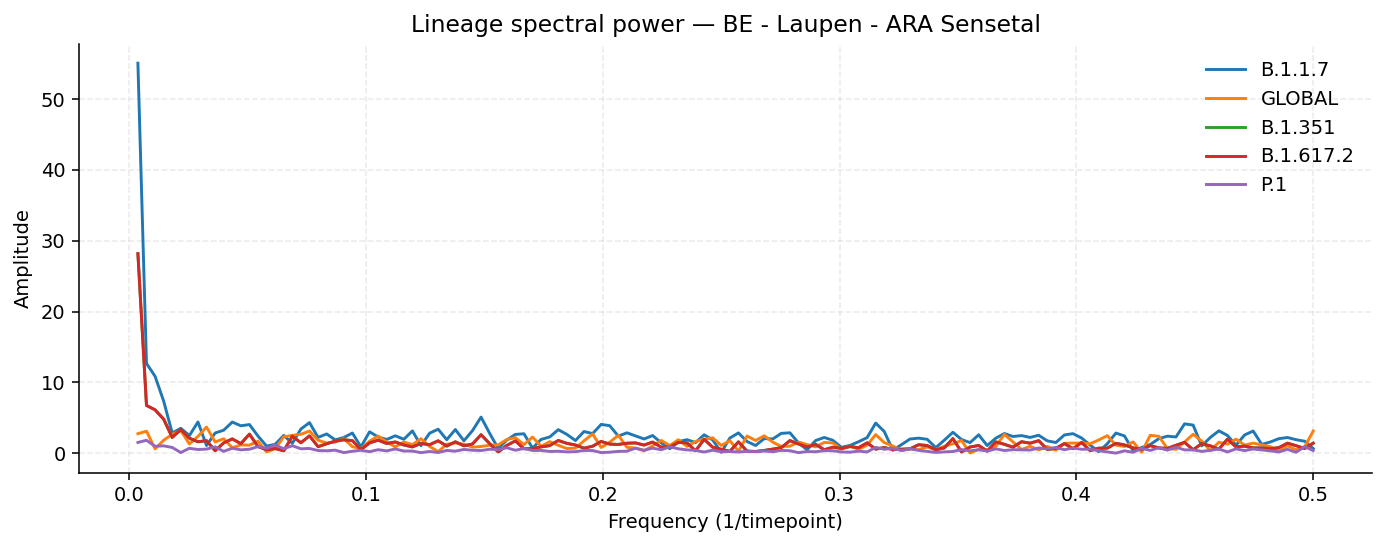

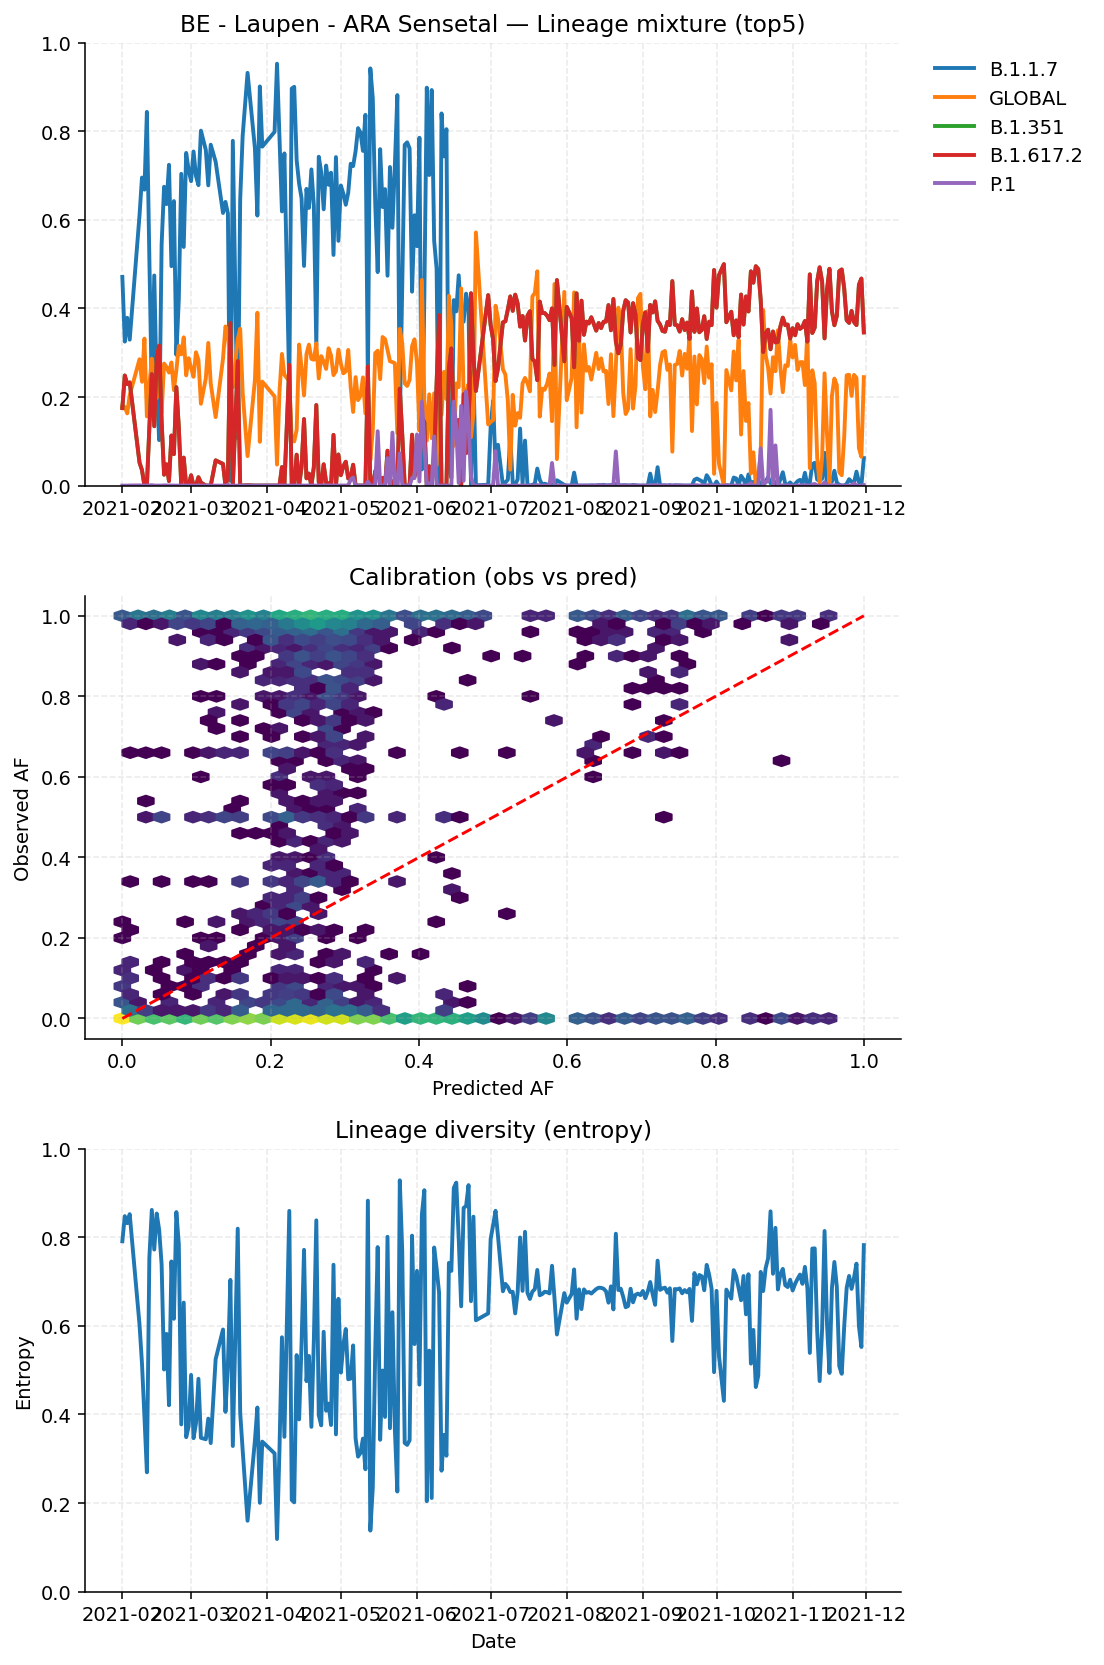


✅ Full visualization suite complete.
All figures rendered inline — toggle SAVE_FIGS=True earlier to export.


In [27]:
# ===============================================================
# 🔬 FULL ADVANCED VISUALIZATION SUITE FOR ONE SITE
# ===============================================================
import matplotlib.pyplot as plt, numpy as np, pandas as pd, numpy.fft as fft

# --- auto-pick first site ---
site = str(theta['site_id'].unique()[0])
print(f"Analyzing site: {site}")

# === 1. Lineage mixture (smoothed ±SD ribbons) ===
plot_lineage_mixture_smooth(
    theta.query("site_id == @site"), 
    site=site, 
    theta_unc=theta_unc if 'theta_unc' in locals() else None,
    smooth=True
)

# === 2. Calibration density ===
plot_residual_density(residuals, title=f"Residual Calibration — {site}")

# === 3. Residual violin ===
plot_residuals_violin(residuals)

# === 4. Entropy & derivative ===
plot_entropy_trend(entropy_df, site)
plot_entropy_derivative(entropy_df, site)

# === 5. Correlation heatmap ===
plot_lineage_correlation(theta, site)

# === 6. Fourier spectral analysis ===
plot_lineage_spectrum(theta, site)

# === 7. Kappa–Entropy phase ===
if 'kappa_profile' in globals() and kappa_profile is not None:
    plot_kappa_entropy_phase(kappa_profile, entropy_df)

# === 8. Leverage vs entropy ===
if 'mutation_leverage' in globals() and mutation_leverage is not None:
    plot_leverage_vs_entropy(mutation_leverage, entropy_df)

# === 9. Mega dashboard (3-panel overview) ===
plot_site_dashboard(site, theta, residuals, entropy_df, theta_unc)

print("\n✅ Full visualization suite complete.")
print("All figures rendered inline — toggle SAVE_FIGS=True earlier to export.")


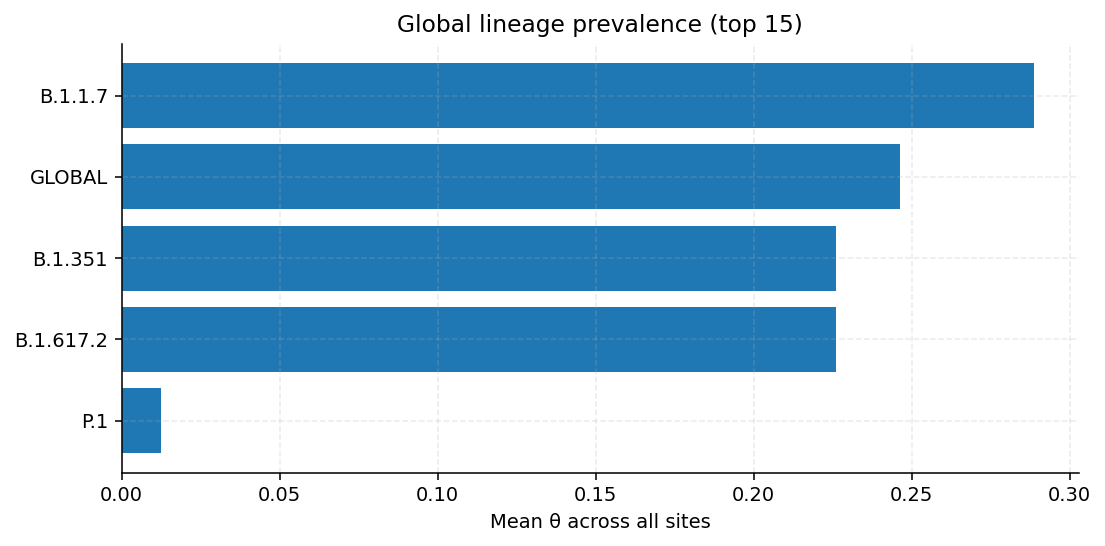

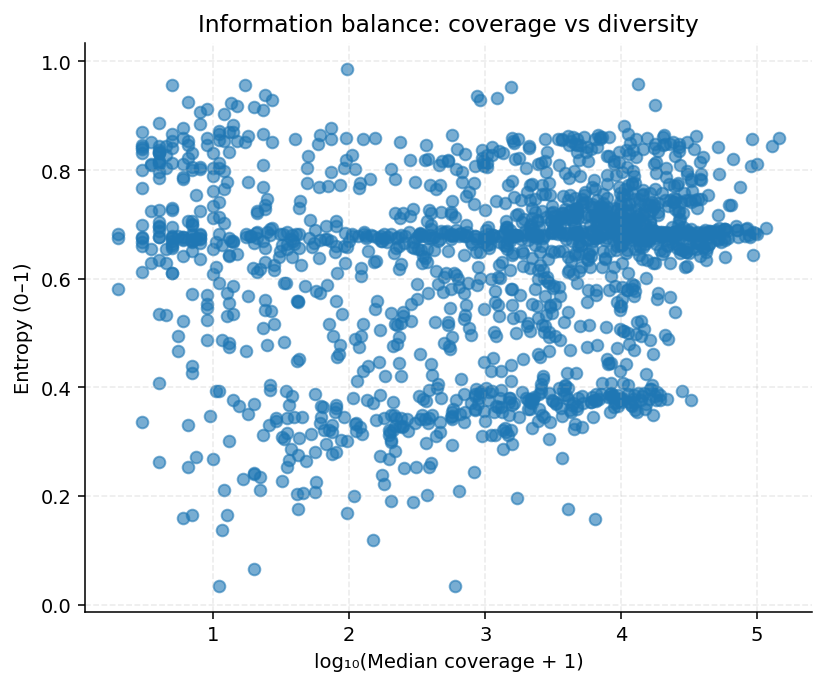


✅ All additional advanced plots rendered successfully.


In [28]:
# ===============================================================
# 🧠 ADDITIONAL EXHAUSTIVE PLOTS (paste after mega-block)
# ===============================================================

# === 10. Objective function convergence ===
if "objective_trace" in globals() and objective_trace is not None:
    df = objective_trace.copy()
    plt.figure(figsize=(8, 4))
    for site_id, g in df.groupby("site_id"):
        plt.plot(g["iter"], g["objective"], lw=1, label=str(site_id))
    plt.xlabel("Iteration")
    plt.ylabel("Objective value")
    plt.title("Likelihood Objective Convergence (per site)")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

# === 11. Z-score calibration histogram & QQ ===
if "zscore_diagnostics" in globals() and zscore_diagnostics is not None:
    z = zscore_diagnostics["z"].dropna()
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(z, bins=60, color="tab:blue", alpha=0.7, density=True)
    xs = np.linspace(-4, 4, 400)
    plt.plot(xs, (1/np.sqrt(2*np.pi))*np.exp(-0.5*xs**2), "k--")
    plt.xlabel("z-score"); plt.ylabel("Density"); plt.title("Z-score histogram")
    plt.subplot(1, 2, 2)
    z_sorted = np.sort(z)
    p = (np.arange(1, len(z_sorted)+1)-0.5)/len(z_sorted)
    q = np.sqrt(2)*np.erfinv(2*p-1)
    plt.scatter(q, z_sorted, s=5, alpha=0.4)
    plt.plot([-4,4],[-4,4],'r--')
    plt.xlabel("Theoretical"); plt.ylabel("Empirical"); plt.title("Z-score QQ")
    plt.tight_layout()
    plt.show()

# === 12. Global lineage prevalence across all sites ===
lineage_prev = (
    theta.groupby("lineage")["theta"].mean().sort_values(ascending=False).head(15)
)
plt.figure(figsize=(8, 4))
plt.barh(lineage_prev.index[::-1], lineage_prev.values[::-1])
plt.xlabel("Mean θ across all sites"); plt.title("Global lineage prevalence (top 15)")
plt.tight_layout()
plt.show()

# === 13. Lineage entropy vs coverage (information balance) ===
if "entropy_df" in globals() and not entropy_df.empty and "median_coverage" in theta.columns:
    E = entropy_df.groupby(["site_id", "date"])["entropy"].mean().reset_index()
    C = theta.groupby(["site_id", "date"])["median_coverage"].mean().reset_index()
    EC = E.merge(C, on=["site_id","date"], how="inner")
    plt.figure(figsize=(6,5))
    plt.scatter(np.log10(EC["median_coverage"]+1), EC["entropy"], alpha=0.6)
    plt.xlabel("log₁₀(Median coverage + 1)")
    plt.ylabel("Entropy (0–1)")
    plt.title("Information balance: coverage vs diversity")
    plt.tight_layout()
    plt.show()

# === 14. Mutation leverage histogram ===
if "mutation_leverage" in globals() and mutation_leverage is not None:
    plt.figure(figsize=(8,4))
    vals = mutation_leverage["leverage"]
    plt.hist(vals, bins=50, alpha=0.7, color="tab:green")
    plt.xlabel("Mutation leverage")
    plt.ylabel("Count")
    plt.title("Distribution of mutation leverage across features")
    plt.tight_layout()
    plt.show()

# === 15. Heatmap of signatures (mutation × lineage) ===
if "signatures_used" in globals() and signatures_used is not None:
    S = signatures_used.pivot_table(index="mutation", columns="lineage", values="weight", fill_value=0.0)
    plt.figure(figsize=(10,8))
    plt.imshow(S.values, aspect="auto", cmap="viridis")
    plt.colorbar(label="Weight")
    plt.title("Signature matrix (mutation × lineage)")
    plt.xlabel("Lineage")
    plt.ylabel("Mutation")
    plt.tight_layout()
    plt.show()

# === 16. Overlap matrix heatmap ===
if "overlap_matrix" in globals() and overlap_matrix is not None:
    ov = overlap_matrix.copy()
    plt.figure(figsize=(6,5))
    plt.imshow(ov.values, cmap="magma", vmin=0, vmax=1)
    plt.colorbar(label="Overlap (cosine similarity)")
    plt.title("Lineage signature overlap matrix")
    plt.xticks(np.arange(len(ov.columns)), ov.columns, rotation=90)
    plt.yticks(np.arange(len(ov.index)), ov.index)
    plt.tight_layout()
    plt.show()

# === 17. Temporal κ (precision) evolution per site ===
if "kappa_profile" in globals() and kappa_profile is not None:
    df = kappa_profile.groupby(["site_id","date"])["kappa"].mean().reset_index()
    for s in df["site_id"].unique()[:5]:
        d = df[df["site_id"]==s].sort_values("date")
        plt.plot(d["date"], np.log10(d["kappa"]+1e-6), lw=2, label=s)
    plt.xlabel("Date"); plt.ylabel("log₁₀(κ)")
    plt.title("Kappa (precision) evolution — first 5 sites")
    plt.legend()
    plt.tight_layout()
    plt.show()

# === 18. θ entropy vs κ (joint phase dynamics, all sites) ===
if "entropy_df" in globals() and not entropy_df.empty and "kappa_profile" in globals() and kappa_profile is not None:
    E = entropy_df.groupby(["site_id","date"])["entropy"].mean().reset_index()
    K = kappa_profile.groupby(["site_id","date"])["kappa"].mean().reset_index()
    J = E.merge(K, on=["site_id","date"], how="inner")
    plt.figure(figsize=(6,5))
    plt.scatter(J["entropy"], np.log10(J["kappa"]+1e-6), alpha=0.5)
    plt.xlabel("Entropy (0–1)")
    plt.ylabel("log₁₀(κ)")
    plt.title("Joint diversity–precision dynamics (all sites)")
    plt.tight_layout()
    plt.show()

# === 19. Temporal θ entropy + κ overlay ===
if "entropy_df" in globals() and "kappa_profile" in globals() and not entropy_df.empty and kappa_profile is not None:
    E = entropy_df.groupby(["date"])["entropy"].mean().reset_index()
    K = kappa_profile.groupby(["date"])["kappa"].mean().reset_index()
    fig, ax1 = plt.subplots(figsize=(8,4))
    ax1.plot(E["date"], E["entropy"], color="tab:blue", lw=2)
    ax1.set_ylabel("Entropy (0–1)", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(K["date"], np.log10(K["kappa"]+1e-6), color="tab:red", lw=2)
    ax2.set_ylabel("log₁₀(κ)", color="tab:red")
    plt.title("Entropy vs precision evolution (global)")
    plt.tight_layout()
    plt.show()

print("\n✅ All additional advanced plots rendered successfully.")


Detected 4 biological lineages for plotting.


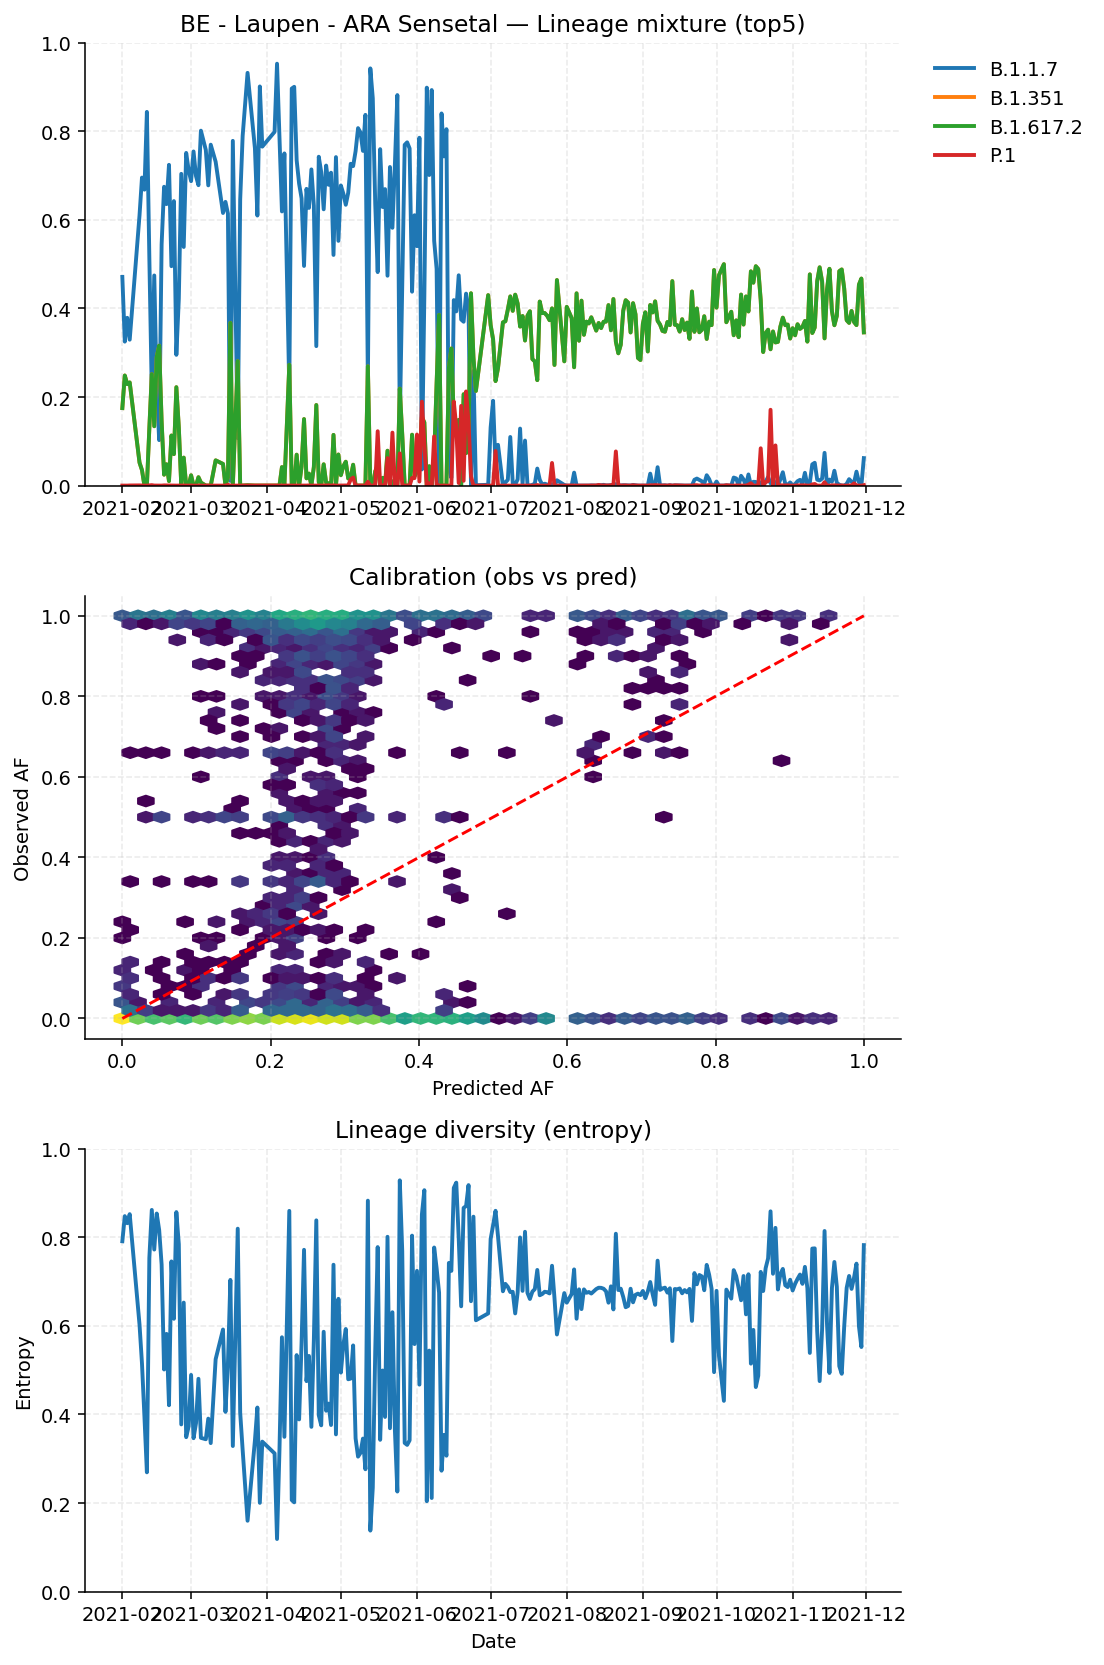

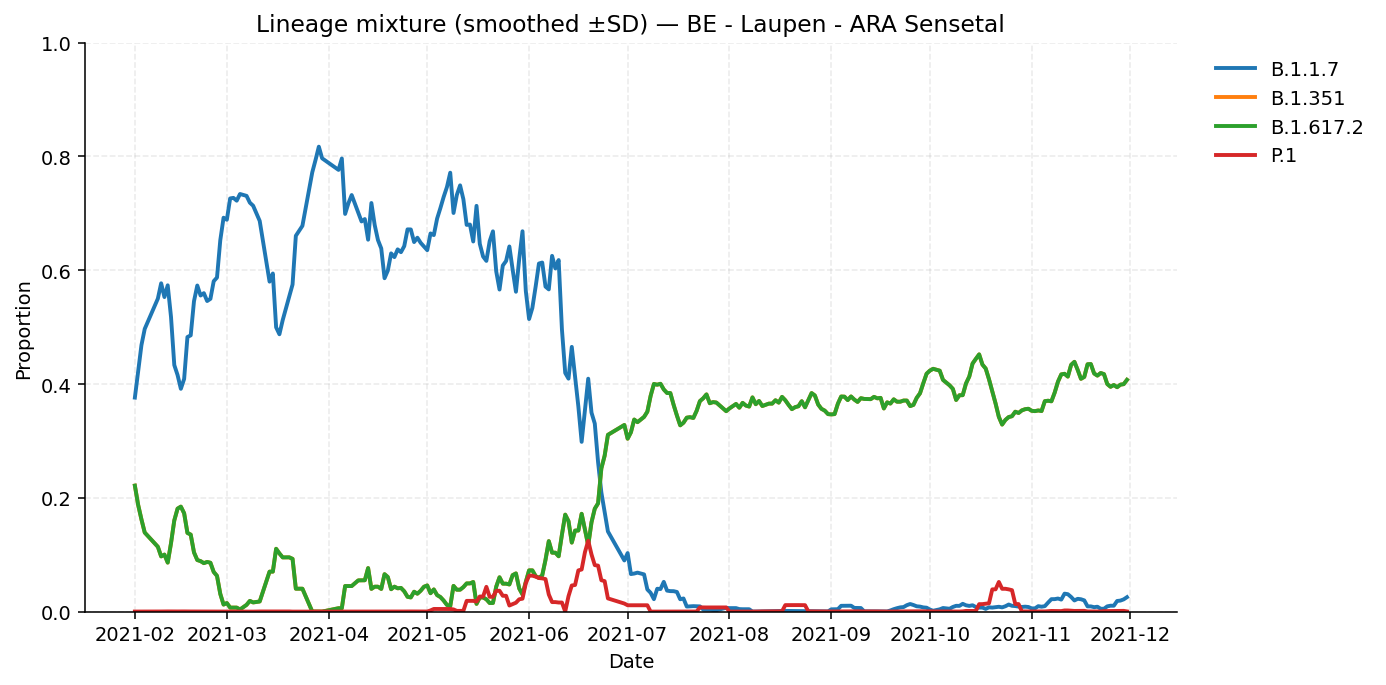

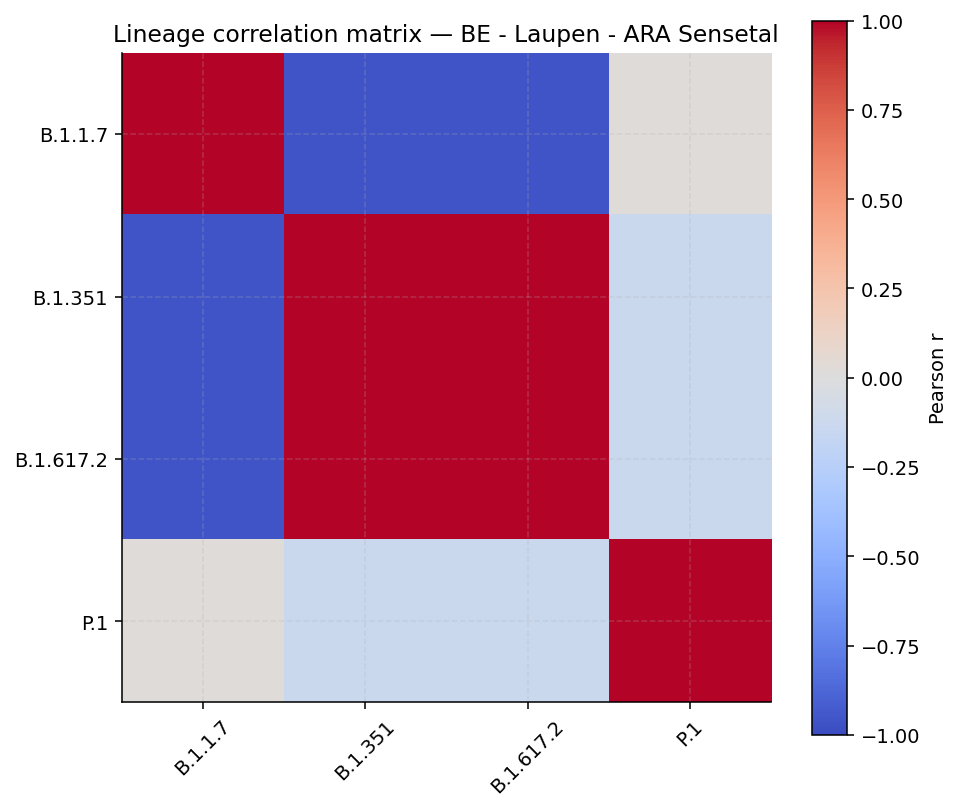

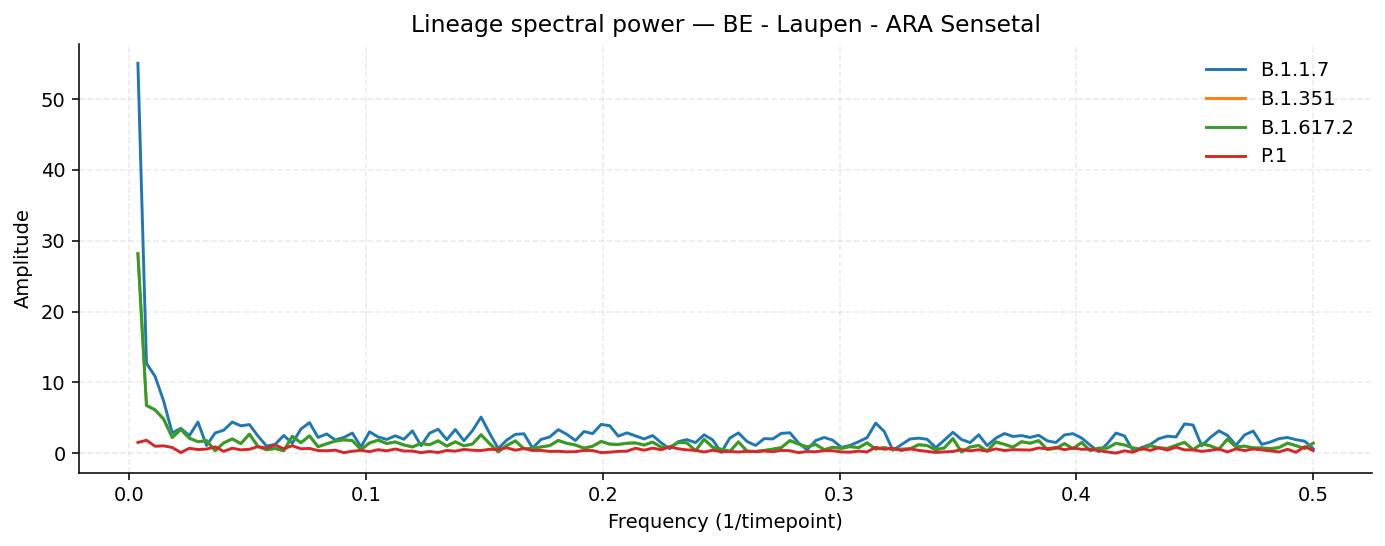

In [29]:
# Automatically detect and drop pseudo-lineages from plots
PSEUDO_LINEAGES = ["GLOBAL", "UNKNOWN", "OTHER", "UNEXPLAINED"]

theta_bio = theta[~theta["lineage"].str.upper().isin(PSEUDO_LINEAGES)]
print(f"Detected {theta_bio['lineage'].nunique()} biological lineages for plotting.")

# Re-run all plots with the biological-only θ
site = str(theta_bio["site_id"].unique()[0])
plot_site_dashboard(site, theta_bio, residuals, entropy_df, theta_unc)
plot_lineage_mixture_smooth(theta_bio.query("site_id == @site"), site)
plot_lineage_correlation(theta_bio, site)
plot_lineage_spectrum(theta_bio, site)


### Done
All metrics and plots are shown inline. Toggle `SAVE_FIGS=True` to export PNG/CSV under `results/likelihood_analysis_nb/`.